**Function 8- Bayesian Optimisation**

# Function 8 Description

You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown.

Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.

# Starting point

* Input - 8D array (40,8)
* Output - 1D array (40,)
* Optimisation goal - Maximise

# Bayesian Optimisation (BO) workflow on capstone project
* BO with Upper Control Bound (UCB)
* Visuals of progress and surrogate intuition
* Final training with the optimized hyperparameters

### Import Libraries

In [2]:
import io, math, pathlib, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm

import warnings
warnings.filterwarnings("ignore")

#### Setup Parameters

In [3]:
plt.rcParams['figure.figsize'] = (5,3)
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.grid'] = True

### Assign Data to variables X and y

In [4]:
import numpy as np, pandas as pd, pathlib

# To load a .npy file into a pandas DataFrame:
# 1. Load the .npy file using numpy.load()
# 2. Convert the resulting numpy array to a pandas DataFrame using pd.DataFrame()

# Attempting to load from '/content/data/' as is common in Colab, or from a 'data/' subfolder
try:
    # Try loading from /content/data/
    X_array = np.load('/content/data/initial_inputs8.npy')
    y_array = np.load('/content/data/initial_outputs8.npy')
    print("Files loaded successfully from /content/data/")

except FileNotFoundError:
    try:
        # If not in /content/data/, try loading from a 'data/' subfolder in the current directory
        X_array = np.load('data/initial_inputs8.npy')
        y_array = np.load('data/initial_outputs8.npy')
        print("Files loaded successfully from data/ subfolder.")
    except FileNotFoundError:
       print("Error: One or both .npy files not found at /content/data/ or data/.")
       print("Please ensure they are in the correct path.")
       print("Current working directory files: ", list(pathlib.Path().absolute().glob('*.npy')))
       print("Files in /content/data/: ", list(pathlib.Path('/content/data/').absolute().glob('*.npy')))

       # Create dummy data if files are not found to allow notebook execution to proceed
       X_array = np.random.rand(40, 8) # Example: 40 samples, 8 features
       y_array = np.random.rand(40,)  # Example: 40 samples, 1 output
       print("\nUsing dummy data for X and y to continue.")

# Convert to DataFrame if needed, or use as NumPy arrays directly for your model
X_df = pd.DataFrame(X_array)
y_df = pd.DataFrame(y_array, columns=['target_output'])

print("Shape of X (NumPy array):", X_array.shape)
print("Shape of y (NumPy array):", y_array.shape)
print("\nFirst 5 rows of X (DataFrame):")
display(X_df.head())
print("\nFirst 5 rows of y (DataFrame):")
display(y_df.head())

# Assign X and y for subsequent steps (as NumPy arrays, based on original notebook context)
X = X_array
y = y_array


Files loaded successfully from /content/data/
Shape of X (NumPy array): (40, 8)
Shape of y (NumPy array): (40,)

First 5 rows of X (DataFrame):


,0,1,2,3,4,5,6,7
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882



First 5 rows of y (DataFrame):


,target_output
0,7.398721
1,7.005227
2,8.459482
3,8.284008
4,8.606117


To add new data points, you'll need to create new NumPy arrays for the input features (`new_X_points`) and target outputs (`new_y_points`). Ensure that the new points have the same number of features as your existing `X` array.

Then, use `np.vstack` to vertically stack the new `X` points onto the existing `X` array, and `np.concatenate` to combine the new `y` points with the existing `y` array.

In [6]:
import numpy as np

# Assume X and y are already defined from previous cells
# Example: X_array.shape = (10, 2), y_array.shape = (10,)

# Create new data points
# Make sure new_X_points has the same number of columns as X
# and new_y_points has compatible dimensions with y

# For X (features), assume 6 features per data point
# Let's add 8 new data points
new_X_points = np.array([
    [0.000005, 0.000005, 0.000005, 0.000005, 0.000005, 0.000005, 0.000005, 0.000005], # week 1 capstone submission - eye ball
    [0.271576, 0.836909, 0.008271, 0.111125, 0.810383, 0.758439, 0.356659, 0.765987], # week 2 capstone submission - KAPPA 30.0 for exploration
    [0.757540, 0.892754, 0.937055, 0.982675, 0.044150, 0.513385, 0.760879, 0.076158], # week 3 capstone submission - KAPPA 30.0 for exploration
    [0.226380, 0.953479, 0.711175, 0.974662, 0.254919, 0.537473, 0.299081, 0.986838], # week 4 capstone submission - KAPPA 100.0 for further exploration
    [0.392539, 0.010871, 0.233747, 0.804415, 0.121383, 0.986474, 0.044503, 0.845197], # week 5 capstone submission - KAPPA 200.0 for further exploration
    [0.709006, 0.988659, 0.967853, 0.023537, 0.792272, 0.912615, 0.119196, 0.754857], # week 6 capstone submission - KAPPA 20.0 for exploitation (although still exploration best x_next offered)
    [0.019463, 0.216758, 0.108154, 0.130474, 0.040834, 0.518456, 0.474894, 0.901294], # week 7 capstone submission, KAPPA 500.00 and changed n_INTER (warm up trials to 30.0 also as wasn't see an improvement in RMSE)
    [0.020441, 0.789350, 0.424723, 0.775914, 0.335781, 0.559681, 0.658750, 0.008306], # week 8 capstone submission, KAPPA 500.00
    [0.232599, 0.839058, 0.008946, 0.802476, 0.078084, 0.003257, 0.025015, 0.883726], # Week 9 capstone submission, KAPPA 1000.00, BO
    [0.376726, 0.108453, 0.226489, 0.115964, 0.956064, 0.999984, 0.217293, 0.703438], # Week 10 capstone submission, KAPPA 1.0, BO
    [0.078277, 0.367647, 0.097463, 0.074745, 0.998667, 0.507789, 0.155741, 0.358426], # Week 11 capstone submission, KAPPA 0.25
    [0.081722, 0.297324, 0.141278, 0.123001, 0.780008, 0.682824, 0.211503, 0.230336]  # Week 12 capstone submission, KAPPA 0.25
 #  [0.119537, 0.156469, 0.024960, 0.255931, 0.821226, 0.546101, 0.184778, 0.409914]  # Week 13 capstone submission, KAPPA 0.10


])

# For y (target), assume a single output value per data point
new_y_points = np.array([
    9.198322499735,  # week 1 capstone processed output
    9.3046303911746, # week 2 capstone processed output
    4.9937924987306, # week 3 capstone processed output
    7.4445578046841, # week 4 capstone processed output
    8.8276474161456, # week 5 capstone processed output
    6.2471509853571, # week 6 capstone processed output
    9.5320395832444, # week 7 capstone processed output
    8.3589942672499, # week 8 capstone processed output
    8.4437224313754, # week 9 capstone processed output
    9.5522004339936, # week 10 capstone processed output
    9.9133002335459, # week 11 capstone processed output
    9.9289627022874  # week 12 capstone processed output
        # week 13 capstone processed output
])


# Verify shapes before adding
print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")
print(f"New X points shape: {new_X_points.shape}")
print(f"New y points shape: {new_y_points.shape}")

# Add the new data points
X = np.vstack([X, new_X_points])
y = np.concatenate([y, new_y_points])

print(f"\nUpdated X shape: {X.shape}")
print(f"Updated y shape: {y.shape}")

# Display the last few rows to see the added data
print("\nLast 5 rows of updated X:")
display(pd.DataFrame(X).tail())
print("\nLast 5 rows of updated y:")
display(pd.DataFrame(y, columns=['target_output']).tail())


Original X shape: (40, 8)
Original y shape: (40,)
New X points shape: (12, 8)
New y points shape: (12,)

Updated X shape: (52, 8)
Updated y shape: (52,)

Last 5 rows of updated X:


,0,1,2,3,4,5,6,7
47,0.020441,0.789350,0.424723,0.775914,0.335781,0.559681,0.658750,0.008306
48,0.232599,0.839058,0.008946,0.802476,0.078084,0.003257,0.025015,0.883726
49,0.376726,0.108453,0.226489,0.115964,0.956064,0.999984,0.217293,0.703438
50,0.078277,0.367647,0.097463,0.074745,0.998667,0.507789,0.155741,0.358426
51,0.081722,0.297324,0.141278,0.123001,0.780008,0.682824,0.211503,0.230336



Last 5 rows of updated y:


,target_output
47,8.358994
48,8.443722
49,9.552200
50,9.913300
51,9.928963


Finding the top 3 input (X) values that generated the highest output (y) values:

Top 3 Highest Output Values (y) and their corresponding X values:
   Original Index: 51
   y value: 9.9289627023e+00
   Corresponding X values: [0.081722 0.297324 0.141278 0.123001 0.780008 0.682824 0.211503 0.230336]


   Original Index: 50
   y value: 9.9133002335e+00
   Corresponding X values: [0.078277 0.367647 0.097463 0.074745 0.998667 0.507789 0.155741 0.358426]


   Original Index: 14
   y value: 9.5984820026e+00
   Corresponding X values: [0.05644741 0.06595555 0.02292868 0.03878647 0.40393544 0.80105533
 0.48830701 0.89308498]


Finding the top 3 input (X) values that generated the lowest output (y) values:

Top 3 Lowest Output Values (y) and their corresponding X values:
   Original Index: 42
   y value: 4.9937924987e+00
   Corresponding X values: [0.75754  0.892754 0.937055 0.982675 0.04415  0.513385 0.760879 0.076158]


   Original Index: 9
   y value: 5.5921933895e+00
   Corresponding X valu

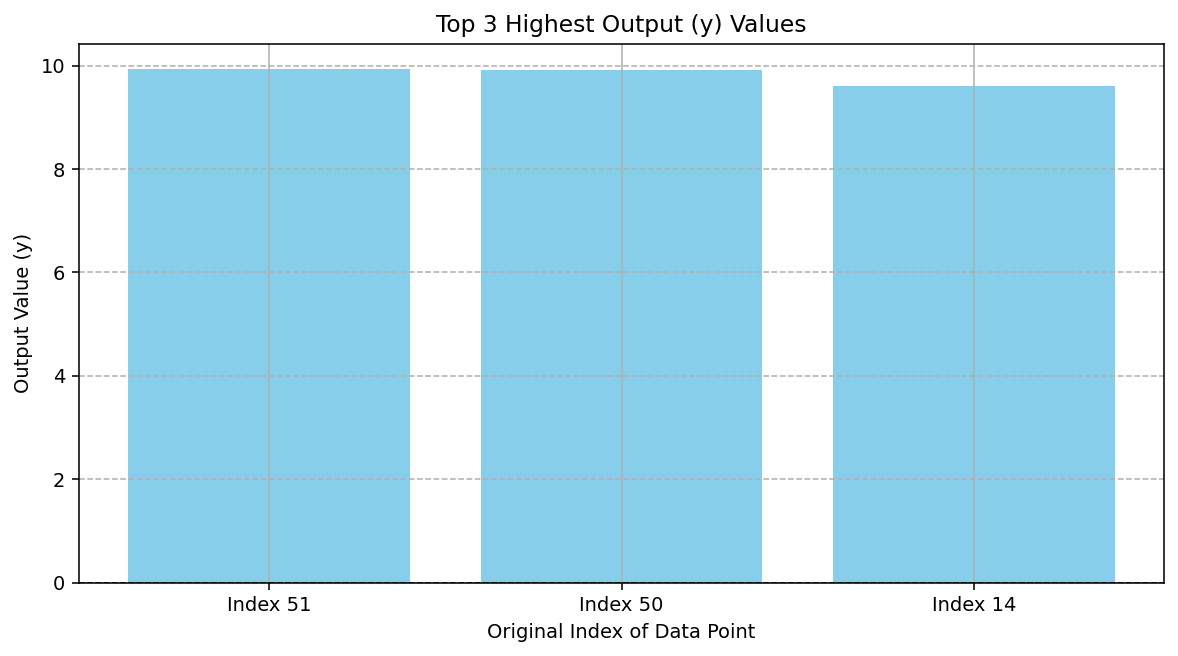

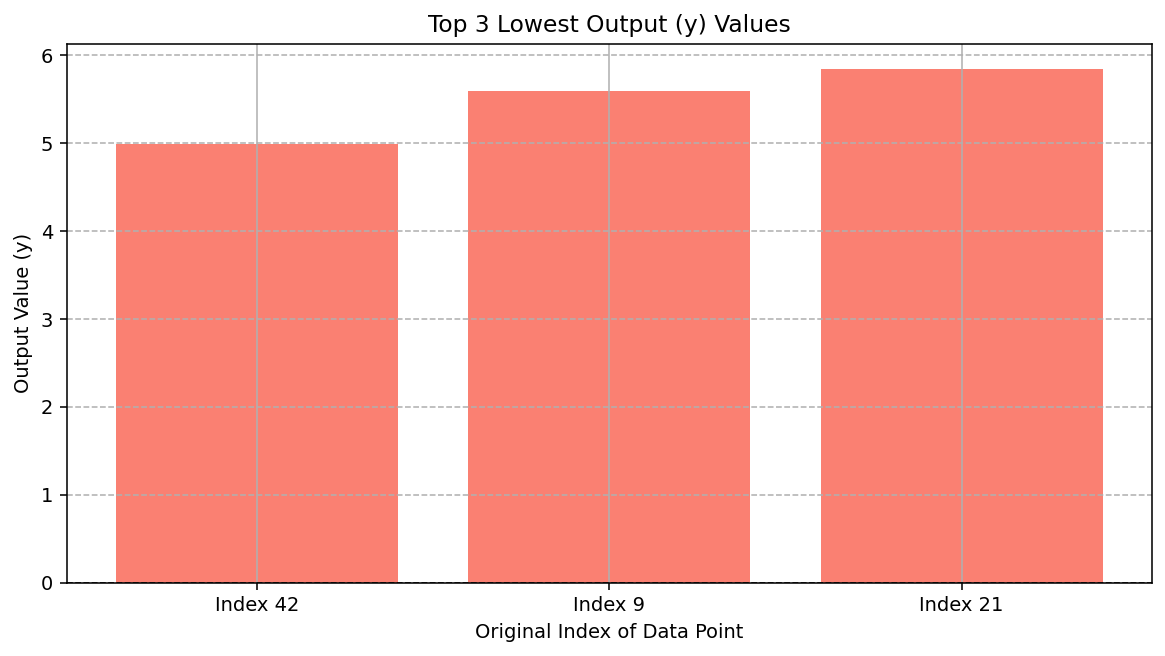

In [8]:
print("Finding the top 3 input (X) values that generated the highest output (y) values:")

# Get indices that would sort y in descending order (highest values are at the beginning)
sorted_indices_highest = np.argsort(y)[::-1]

# Select the top 3 indices for the highest y values
top_3_indices_highest = sorted_indices_highest[:3]

# Get the corresponding X and y values
top_3_X_highest = X[top_3_indices_highest]
top_3_y_highest = y[top_3_indices_highest]

print("\nTop 3 Highest Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_highest):
  print(f"   Original Index: {top_3_indices_highest[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_highest[i]}")
  print("\n")

print("Finding the top 3 input (X) values that generated the lowest output (y) values:")

# Get indices that would sort y in ascending order (lowest values are at the beginning)
sorted_indices_lowest = np.argsort(y)

# Select the top 3 indices for the lowest y values
top_3_indices_lowest = sorted_indices_lowest[:3]

# Get the corresponding X and y values
top_3_X_lowest = X[top_3_indices_lowest]
top_3_y_lowest = y[top_3_indices_lowest]

print("\nTop 3 Lowest Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_lowest):
  print(f"   Original Index: {top_3_indices_lowest[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_lowest[i]}")
  print("\n")

# Plotting the top 3 highest y values
plt.figure(figsize=(10, 5))
plt.bar([f'Index {idx}' for idx in top_3_indices_highest], top_3_y_highest, color='skyblue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Added baseline at y=0
plt.xlabel('Original Index of Data Point')
plt.ylabel('Output Value (y)')
plt.title('Top 3 Highest Output (y) Values')
plt.grid(axis='y', linestyle='--')
plt.show()

# Plotting the top 3 lowest y values
plt.figure(figsize=(10, 5))
plt.bar([f'Index {idx}' for idx in top_3_indices_lowest], top_3_y_lowest, color='salmon')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Added baseline at y=0
plt.xlabel('Original Index of Data Point')
plt.ylabel('Output Value (y)')
plt.title('Top 3 Lowest Output (y) Values')
plt.grid(axis='y', linestyle='--')
plt.show()

### Objective and baseline
Baseline model provides us the RMSE benchmark as a starting point

In [9]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)
def rmse_cv(model):
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    return float(np.sqrt(-scores).mean())

baseline = GradientBoostingRegressor(random_state=42)
baseline_rmse = rmse_cv(baseline)
print(f"Baseline GBR RMSE (5-fold): {baseline_rmse:.3f}")

Baseline GBR RMSE (5-fold): 0.473


### Search Space and Helper Functions

In [11]:
# Search space for 8D input (n_estimators, learning_rate, max_depth, subsample, min_samples_leaf, max_features, min_samples_split, min_weight_fraction_leaf)
space = {
    "n_estimators": (50, 400),        # Integer
    "learning_rate": (0.01, 0.30),    # Float
    "max_depth": (1, 10),             # Integer
    "subsample": (0.5, 1.0),          # Float
    "min_samples_leaf": (1, 20),      # Integer
    "max_features": (0.0, 1.0),       # Categorical, mapped from float (0.0=sqrt, 1.0=log2)
    "min_samples_split": (2, 20),     # Integer
    "min_weight_fraction_leaf": (0.0, 0.5) # Float
}
hp = list(space.keys()); d = len(hp) # d will now be 8

# Converts normalized values in [0,1] into actual hyperparameter values (and rounds when needed, e.g., integers)
def to_params(x01):
    out = {}
    for i, name in enumerate(hp):
        lo, hi = space[name]
        v = lo + x01[i]*(hi-lo)
        if name in ["n_estimators", "max_depth", "min_samples_leaf", "min_samples_split"]:
            v = int(round(v))
        elif name == "max_features":
            # Map float to 'sqrt' or 'log2'
            v = "sqrt" if x01[i] < 0.5 else "log2"
        out[name] = v if name == "max_features" else float(v) # Store all as float initially, cast to int/str where needed
    return out

# Builds a GradientBoostingRegressor with given params and returns its 5-fold CV RMSE. So BO minimizes error (RMSE)
def objective(params):
    model = GradientBoostingRegressor(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        max_features=params["max_features"], # Use the new max_features parameter
        min_samples_split=int(params["min_samples_split"]),
        min_weight_fraction_leaf=float(params["min_weight_fraction_leaf"]),
        random_state=42
    )
    return rmse_cv(model)

# The normal_pdf and normal_cdf functions remain unchanged
def normal_pdf(z):
    # Using scipy.stats.norm for robustness, assuming it's available from initial imports
    return norm.pdf(z)

def normal_cdf(z):
    # Using scipy.stats.norm for robustness, assuming it's available from initial imports
    return norm.cdf(z)

### Step by Step BO with UCB decomposition

#### Import Libraries

In [12]:
from dataclasses import dataclass
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np, pandas as pd, matplotlib.pyplot as plt

#### Dataclass to store all details of each step in the optimization

In [13]:
@dataclass
class StepLog:
    it: int; params: dict; rmse: float; mu: float; sigma: float; ei: float
    exploit_contrib: float; explore_contrib: float; tag: str; best_rmse: float

**Control the knobs for the BO run**
* N_INIT = number of warm-up random trials before BO starts learning
* N_ITER = number of BO-guided iterations
* KAPPA = exploration bias parameter for Upper Confidence Bound (UCB)
* N_CAND = how many candidate points to evaluate at each step
* rng = random generator for reproducibility

In [14]:
N_INIT, N_ITER, KAPPA, N_CAND = 8, 20.0, 0.10, 2000   # week 13
#N_INIT, N_ITER, KAPPA, N_CAND = 8, 20.0, 0.25, 2000  # week 12
#N_INIT, N_ITER, KAPPA, N_CAND = 8, 20.0, 0.25, 2000  # week 11
rng = np.random.RandomState(123)

#### Warm-up trials - BO needs some initial data to train the surrogate

In [15]:
X_trials = rng.rand(N_INIT, d)
y_trials = np.array([objective(to_params(x)) for x in X_trials])
best_rmse = float(np.min(y_trials))

#### Initialize logging with warm-up trials
Will be tagged as Warm-up

In [16]:
logs = []
cum_best = np.minimum.accumulate(y_trials)
for i in range(N_INIT):
    logs.append(StepLog(i-(N_INIT-1), to_params(X_trials[i]), float(y_trials[i]), float('nan'), float('nan'),
                        float('nan'), float('nan'), float('nan'), "Warm-up", float(cum_best[i])))

#### Define surrogate (Gaussian Process)
This is the GP surrogate model that predicts mean (mu) and uncertainty (sigma)

In [17]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=3)

trace = [best_rmse]

#### Bayesian Optimization loop
For Each iteration:
1. Fit surrogate
2. Predict many candidates
3. Compute UCB
4. Pick best candidate
5. Classify step as Exploration/Exploitation
6. Evaluate real objective
7. Update logs and best_rmse

In [18]:
for it in range(1, int(N_ITER)+1):
    # Fit surrogate on all past trials
    gpr.fit(X_trials, y_trials)

    # Generate candidate points and predict mean/uncertainty
    CAND = rng.rand(N_CAND, d)
    mu, std = gpr.predict(CAND, return_std=True)

    # Compute Upper Confidence Bound (UCB) for each candidate
    # UCB = mu + KAPPA * std. We want to maximize this.
    ucb = mu + KAPPA * std

    # Pick the candidate with maximum UCB
    idx = int(np.argmax(ucb)); x_next = CAND[idx]
    mu_star, sig_star = float(mu[idx]), float(std[idx])
    # EI-related values are not directly applicable to UCB, setting to NaN or 0
    ei_star = float('nan')
    imp_star = float('nan')
    z_star = float('nan')

    # UCB is inherently a balance of exploitation (mu) and exploration (std*KAPPA)
    # We can approximate contribution for logging, or simply tag as 'UCB'
    contrib_exploit = float(mu[idx]) # Exploitation is driven by the mean prediction
    contrib_explore = float(KAPPA * std[idx]) # Exploration is driven by uncertainty weighted by KAPPA
    tag = "UCB (Exploration)" if KAPPA * std[idx] > abs(mu[idx]) else "UCB (Exploitation)"

    # Evaluate true objective at chosen point
    params_next = to_params(x_next); y_next = objective(params_next)
    X_trials = np.vstack([X_trials, x_next[None,:]])
    y_trials = np.concatenate([y_trials, [y_next]])
    if y_next < best_rmse: best_rmse = float(y_next)
    trace.append(best_rmse)

    # Log the step
    logs.append(StepLog(it, params_next, float(y_next), mu_star, sig_star, ei_star,
                        contrib_exploit, contrib_explore, tag, best_rmse))


#### Log final step log DataFrame

In [19]:
log_df = pd.DataFrame([{
    "iter": s.it, "tag": s.tag, "rmse": s.rmse, "best_rmse_so_far": s.best_rmse,
    "mu": s.mu, "sigma": s.sigma, "ei": s.ei,
    "exploit_contrib": s.exploit_contrib, "explore_contrib": s.explore_contrib,
    **{k: s.params[k] for k in s.params}
} for s in logs])
log_df.head(40)

,iter,tag,rmse,best_rmse_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf,max_features,min_samples_split,min_weight_fraction_leaf
0,-7,Warm-up,0.573330,0.573330,NaN,NaN,NaN,NaN,NaN,294.0,0.092980,3.0,0.775657,15.0,sqrt,20.0,0.342415
1,-6,Warm-up,0.520090,0.520090,NaN,NaN,NaN,NaN,NaN,218.0,0.123714,4.0,0.864525,9.0,sqrt,9.0,0.368998
2,-5,Warm-up,0.518875,0.518875,NaN,NaN,NaN,NaN,NaN,114.0,0.060881,6.0,0.765914,13.0,log2,15.0,0.305512
3,-4,Warm-up,0.434310,0.434310,NaN,NaN,NaN,NaN,NaN,303.0,0.103658,4.0,0.614132,7.0,log2,4.0,0.216851
4,-3,Warm-up,0.492295,0.434310,NaN,NaN,NaN,NaN,NaN,201.0,0.153169,5.0,0.656131,9.0,log2,19.0,0.250918
5,-2,Warm-up,1.138310,0.434310,NaN,NaN,NaN,NaN,NaN,268.0,0.043529,4.0,0.707413,17.0,sqrt,11.0,0.492780
6,-1,Warm-up,0.480264,0.434310,NaN,NaN,NaN,NaN,NaN,232.0,0.187739,2.0,0.913170,12.0,log2,8.0,0.152060
7,0,Warm-up,0.558461,0.434310,NaN,NaN,NaN,NaN,NaN,196.0,0.207577,9.0,0.755211,14.0,log2,13.0,0.337345
8,1,UCB (Exploitation),1.146180,0.434310,1.182690,0.054504,NaN,1.182690,0.005450,301.0,0.277871,9.0,0.534099,20.0,sqrt,6.0,0.488654
9,2,UCB (Exploitation),1.147877,0.434310,1.156306,0.014244,NaN,1.156306,0.001424,322.0,0.174155,8.0,0.791942,18.0,sqrt,9.0,0.498434


### Visuals

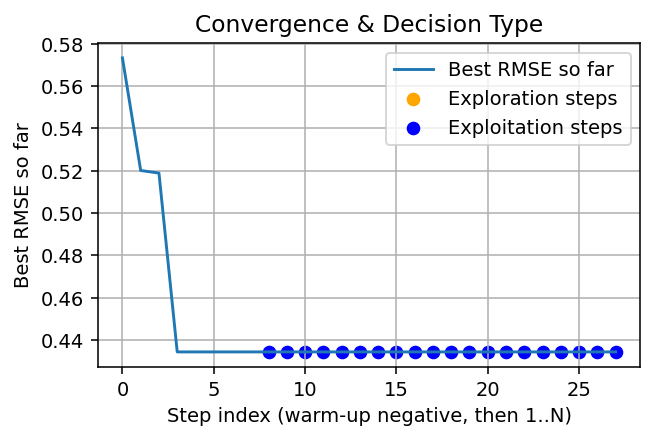

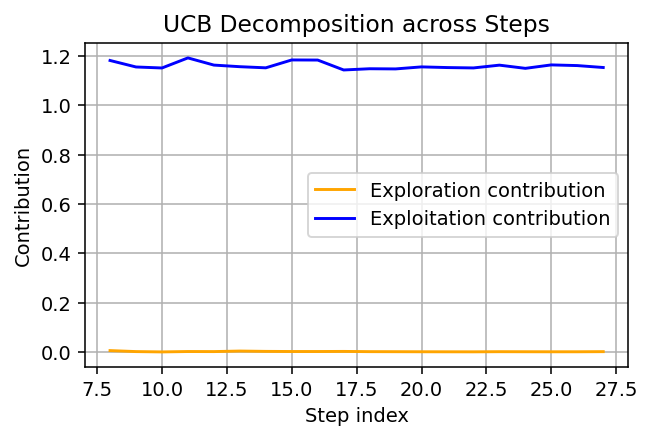

In [20]:
mask_explr = log_df["tag"] == "UCB (Exploration)"; mask_explt = log_df["tag"] == "UCB (Exploitation)"

plt.figure()
plt.plot(log_df["best_rmse_so_far"], label="Best RMSE so far")
plt.scatter(log_df.index[mask_explr], log_df.loc[mask_explr, "best_rmse_so_far"], label="Exploration steps", color="orange")
plt.scatter(log_df.index[mask_explt], log_df.loc[mask_explt, "best_rmse_so_far"], label="Exploitation steps", color="blue")
plt.xlabel("Step index (warm-up negative, then 1..N)"); plt.ylabel("Best RMSE so far")
plt.title("Convergence & Decision Type"); plt.legend(); plt.show()

plt.figure()
plt.plot(log_df["explore_contrib"], label="Exploration contribution",color="orange")
plt.plot(log_df["exploit_contrib"], label="Exploitation contribution", color="blue")
plt.xlabel("Step index"); plt.ylabel("Contribution")
plt.title("UCB Decomposition across Steps"); plt.legend(); plt.show()

In [21]:
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Best RMSE found: {log_df['best_rmse_so_far'].min():.4f}")

Baseline RMSE: 0.4726
Best RMSE found: 0.4343


#### Surrogate slice: initial vs final (all Hyperparameters)
Fits a Gaussian Process surrogate on the current trials (X_used, y_used)

Generating surrogate slice plots for each continuous hyperparameter...


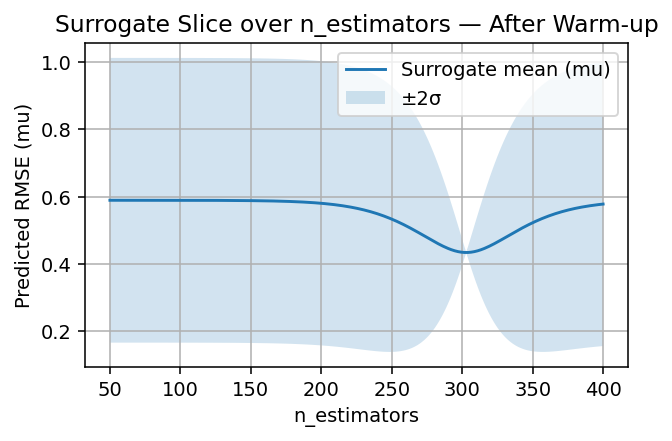

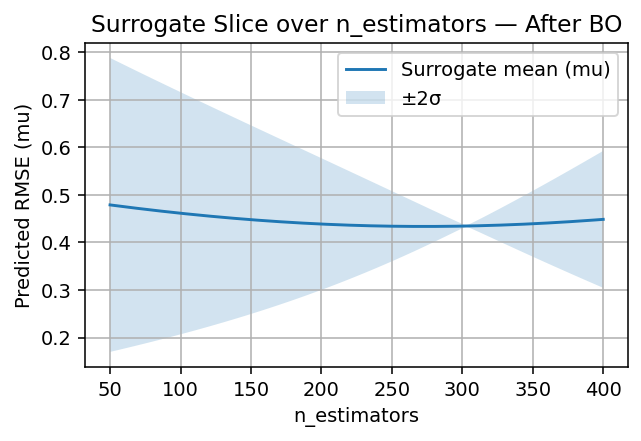

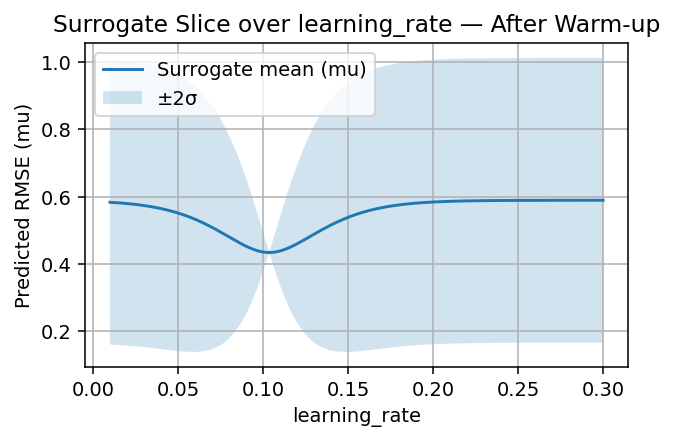

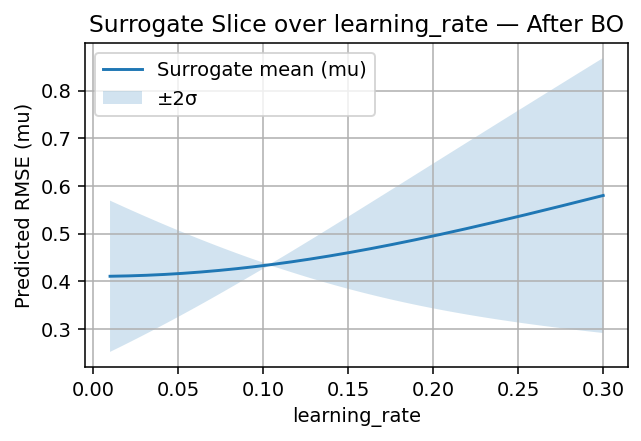

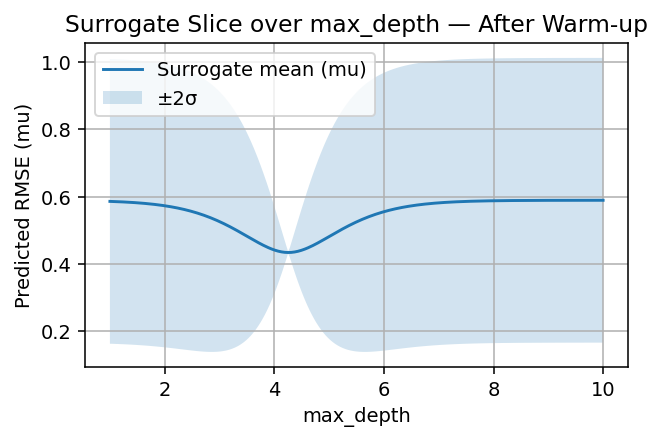

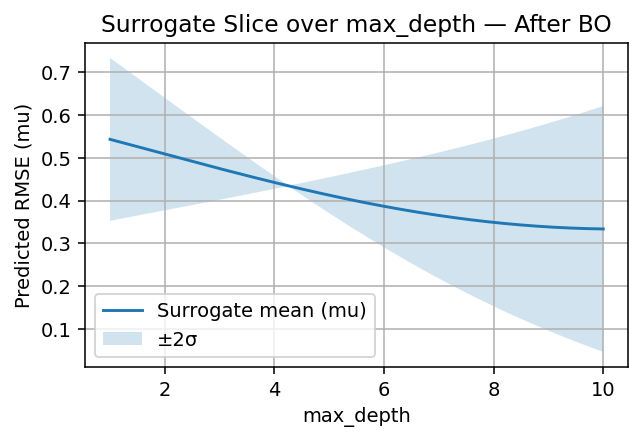

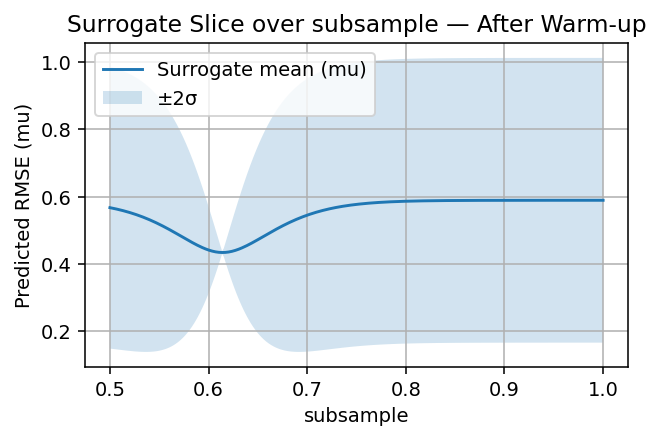

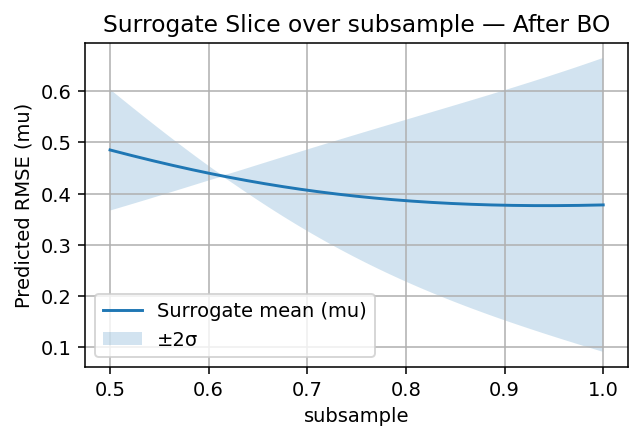

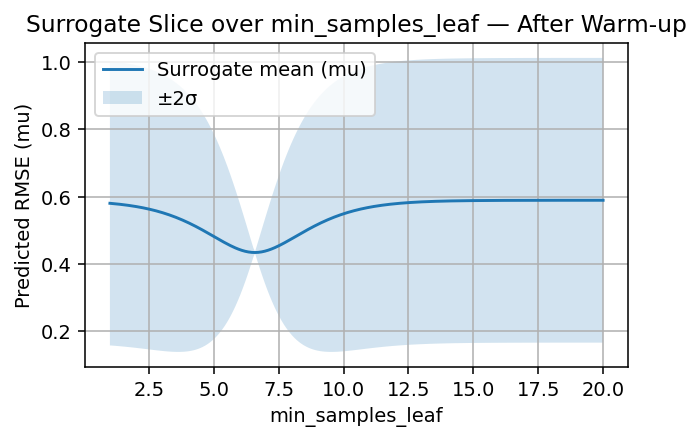

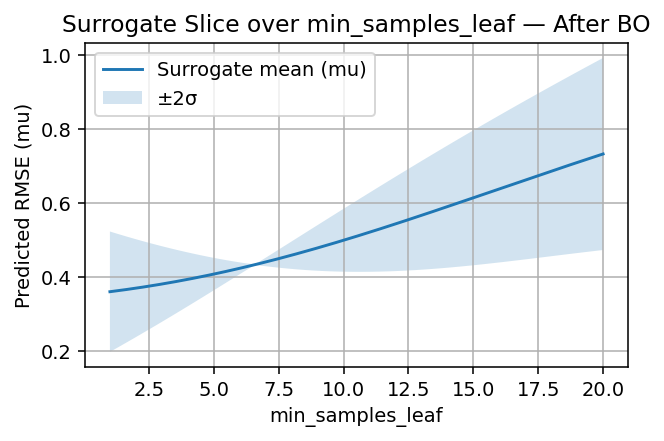

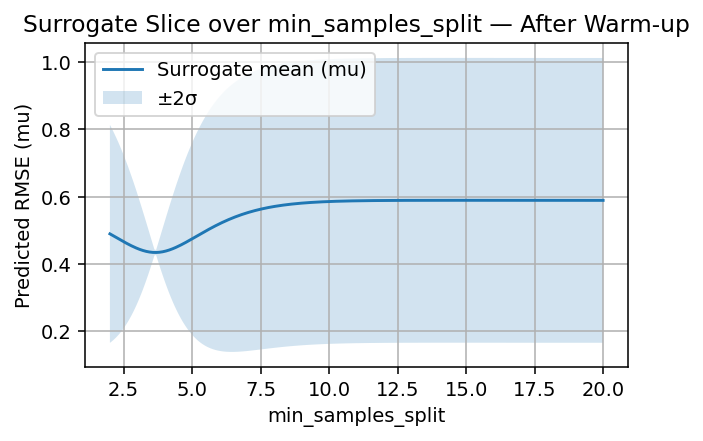

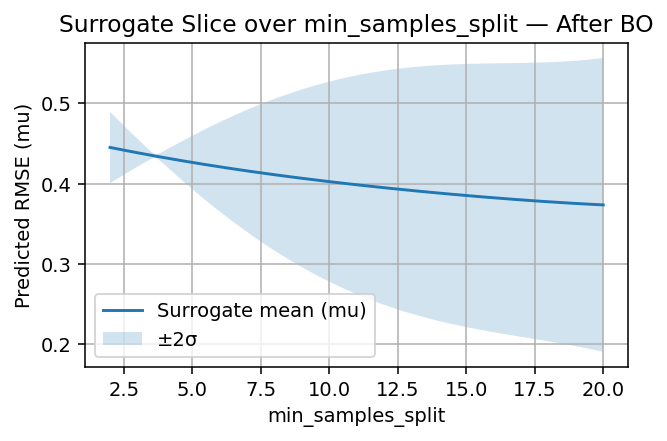

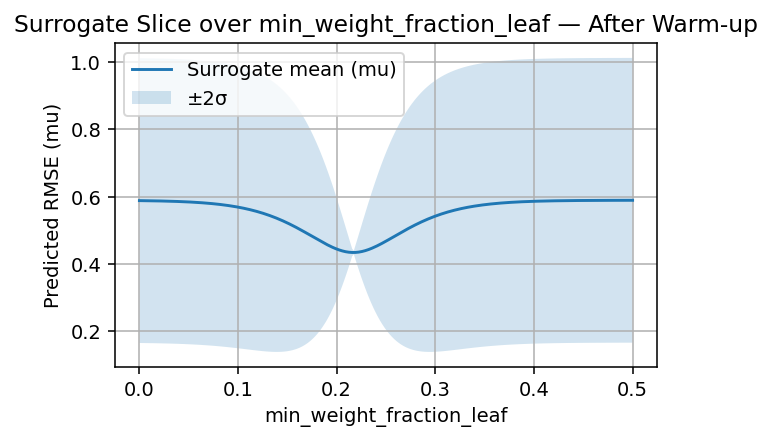

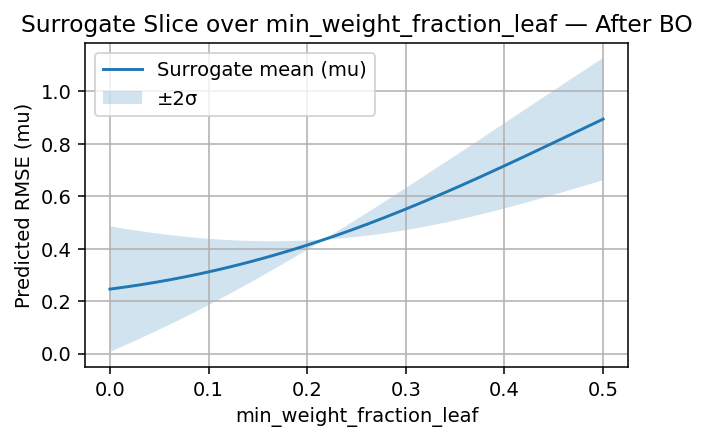


All requested surrogate slice plots have been generated.
The `log_df` shows the entire optimization process, with 28 steps recorded, including 8 warm-up trials and 20 BO-guided iterations.
The best RMSE found during the optimization was 0.434.


In [22]:
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np

# Define the generalized surrogate slice plot function
def plot_surrogate_slice_for_hp(X_used, y_used, hp_name, title_suffix, space_dict):
    gp = GaussianProcessRegressor(kernel=C(1.0)*Matern(nu=2.5)+WhiteKernel(1e-6), normalize_y=True, random_state=0)
    gp.fit(X_used, y_used)

    best_idx = np.argmin(y_used); anchor = X_used[best_idx].copy()
    j = list(space_dict.keys()).index(hp_name)
    xs = np.linspace(0,1,300); grid = np.tile(anchor, (len(xs),1)); grid[:, j] = xs
    lo, hi = space_dict[hp_name]

    # Only plot continuous hyperparameters as a slice
    if hp_name == "max_features":
        print(f"Skipping continuous slice plot for categorical hyperparameter: {hp_name}")
        return

    hp_vals = lo + xs*(hi-lo)

    mu, std = gp.predict(grid, return_std=True)

    plt.figure()
    plt.plot(hp_vals, mu, label="Surrogate mean (mu)")
    plt.fill_between(hp_vals, mu-2*std, mu+2*std, alpha=0.2, label="±2σ")
    plt.xlabel(hp_name); plt.ylabel("Predicted RMSE (mu)")
    plt.title(f"Surrogate Slice over {hp_name} — {title_suffix}")
    plt.legend(); plt.show()

# Get warm-up data for plotting using N_INIT (assuming N_INIT is defined globally)
X_warm_plot = globals()['X_trials'][:N_INIT]
y_warm_plot = np.array([objective(to_params(x)) for x in X_warm_plot])

# Get full BO data for plotting (X_trials and y_trials contain all data after BO)
X_full_plot = globals()['X_trials']
y_full_plot = globals()['y_trials']

# Iterate through all continuous hyperparameters to generate plots
continuous_hps = [hp_name for hp_name in space.keys() if hp_name != "max_features"]

print("Generating surrogate slice plots for each continuous hyperparameter...")

for current_hp in continuous_hps:
    # After Warm-up
    plot_surrogate_slice_for_hp(X_warm_plot, y_warm_plot, current_hp, "After Warm-up", space)
    # After BO
    plot_surrogate_slice_for_hp(X_full_plot, y_full_plot, current_hp, "After BO", space)

print("\nAll requested surrogate slice plots have been generated.")
print(f"The `log_df` shows the entire optimization process, with {len(log_df)} steps recorded, including {N_INIT} warm-up trials and {int(N_ITER)} BO-guided iterations.")
print(f"The best RMSE found during the optimization was {log_df['best_rmse_so_far'].min():.3f}.")


**Weekly Strategy**

1.   Week 4 ,using a KAPPA of 100.0, the next best candidate offered was [0.226380, 0.953479, 0.711175, 0.974662, 0.254919, 0.537473, 0.299081, 0.986838]
2.  Week 5, using a KAPPA of 200.0, the next best candidate offered was [0.39253912, 0.01087121, 0.23374711, 0.80441517, 0.12138304, 0.98647418, 0.04450286, 0.84519704]
3. Week 6, using a KAPPA of 20.0 (still exploration), the next best candidate offered was [0.70900558, 0.98865916, 0.96785267, 0.02353657, 0.79227216, 0.91261513, 0.11919576, 0.75485742]
4. Week 7, using a KAPPA of 500.0 (exploration), the next best candidate offered was [0.01946246, 0.2167583 , 0.10815417, 0.13047408, 0.04083375, 0.51845608, 0.47489443, 0.90129429], changed n_INTER (warm up trials to 30.0 also as wasn't see an improvement in RMSE)

# Hyperameter Tuning Consideration

**For Week 8**

After adding Week 7 data points, and running the iteration for Week 8, I could see the surrogate slice plots After BO were showing an improvement in their shape for the different hyperparameters.

The Residuals plot also changed to showing a more acceptable shape compared to previous week showing that the surrogate model is learning.

Therefore for week 8 I decided to stay with the current settings of KAPPA 500 and the same hyperparameter settings (I had only changed the N_INTER to 30 trials from 8 in Week 7)

Week 8 best candidate offered is [0.02044087, 0.78935005, 0.42472329, 0.77591417, 0.33578093, 0.55968062, 0.6587501 , 0.00830603]

# **Week 9 using a KAPPA of 1000**

 - Suggested next X data point (8D coordinates): [0.23259853 0.83905825 0.00894633 0.8024758  0.0780837  0.00325742
 0.02501519 0.8837264 ]
 - Predicted Y at this point (mean, Negative RMSE): 8.41571e+00
 - Predicted uncertainty (std) at this point: 1.82977e-01
 - UCB value at this point: 1.91393e+02

### **Week 10 using a KAPPA of 1.0 for exploitation**

 - Suggested next X data point (8D coordinates): [0.37672638 0.10845271 0.22648903 0.11596404 0.95606402 0.9999842
 0.21729332 0.70343788]
 - Predicted Y at this point (mean, Negative RMSE): 9.90929e+00
 - Predicted uncertainty (std) at this point: 1.18350e-01
 - UCB value at this point: 1.00276e+01

### **Week 11 using a KAPPA of 0.25 for exploitation**

 - Suggested next X data point (8D coordinates): [0.07827664 0.36764656 0.09746253 0.0747451  0.99865698 0.50778914
 0.15574122 0.35842554]
 - Predicted Y at this point (mean, Negative RMSE): 9.96405e+00
 - Predicted uncertainty (std) at this point: 6.11427e-02
 - UCB value at this point: 9.97934e+00

### **Week 12 using a KAPPA of 0.25 for exploitation**

 - Suggested next X data point (8D coordinates): [0.08172185 0.29732409 0.14127756 0.12300144 0.78000781 0.68282363
 0.21150316 0.23033558]
 - Predicted Y at this point (mean, Negative RMSE): 9.91082e+00
 - Predicted uncertainty (std) at this point: 2.19229e-02
 - UCB value at this point: 9.91630e+00

### **Week 13 using a KAPPA of 0.10**

- Suggested next X data point (8D coordinates): [0.11953696 0.15646891 0.02495981 0.25593076 0.82122589 0.54610068
 0.18477835 0.40991395]
 - Predicted Y at this point (mean, Negative RMSE): 9.92221e+00
 - Predicted uncertainty (std) at this point: 2.99943e-02
 - UCB value at this point: 9.92521e+00

### Final Model (on best parameters)

Optimized hyperparameters (from BO): {'n_estimators': 303, 'learning_rate': 0.10365808501742167, 'max_depth': 4, 'subsample': 0.6141316154394778, 'min_samples_leaf': 7, 'max_features': 'log2', 'min_samples_split': 4.0, 'min_weight_fraction_leaf': 0.21685058633976412}
Final (BO) 5-fold RMSE: 0.434


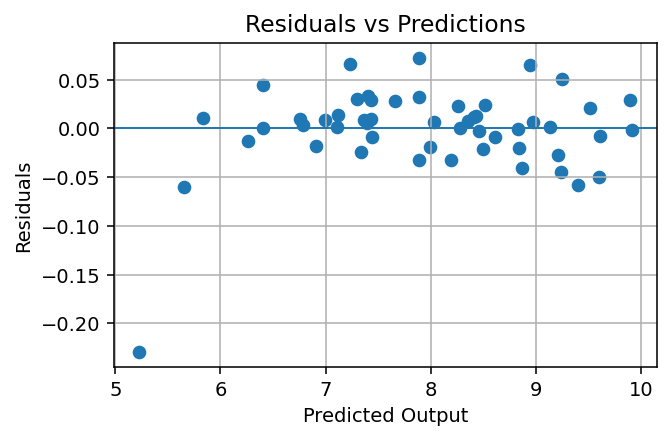

In [23]:
# The original values for max_depth and subsample were fixed within the objective function.
# We need to use those same fixed values here to initialize the final model.
# However, with the 6D optimization, max_depth and subsample are now optimized by BO.
# We should use the optimized values from best_params for the final model.

best_row = log_df.iloc[log_df["best_rmse_so_far"].idxmin()]
best_params = {}
for k in space.keys():
    if k == "max_features":
        best_params[k] = best_row[k] # Keep as string
    else:
        best_params[k] = float(best_row[k])

# Ensure integer hyperparameters are correctly cast
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])
best_params["min_samples_leaf"] = int(best_params["min_samples_leaf"])

print("Optimized hyperparameters (from BO):", best_params)

final = GradientBoostingRegressor(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"], # Use the BO-optimized value
    subsample=best_params["subsample"], # Use the BO-optimized value
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"], # Use the BO-optimized value (string 'sqrt' or 'log2')
    random_state=42
)
final_rmse = rmse_cv(final)
print("Final (BO) 5-fold RMSE:", round(final_rmse, 3))

final.fit(X, y)
pred = final.predict(X)
resid = y - pred # Corrected: subtract predictions from actual target values (y)

plt.figure()
plt.scatter(pred, resid)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted Output"); plt.ylabel("Residuals") # Changed label for generality
plt.title("Residuals vs Predictions")
plt.show()

### Log review (each step)

In [24]:
try:
    import caas_jupyter_tools as cj
    subset_cols = ["iter","tag","rmse","best_rmse_so_far","mu","sigma","ei","exploit_contrib","explore_contrib"] + list(space.keys())
    log_view = log_df[subset_cols].round(4)
    cj.display_dataframe_to_user("BayesOpt_Step_Log", log_view)
except Exception:
    pass

log_df.head(20)

,iter,tag,rmse,best_rmse_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf,max_features,min_samples_split,min_weight_fraction_leaf
0,-7,Warm-up,0.573330,0.573330,NaN,NaN,NaN,NaN,NaN,294.0,0.092980,3.0,0.775657,15.0,sqrt,20.0,0.342415
1,-6,Warm-up,0.520090,0.520090,NaN,NaN,NaN,NaN,NaN,218.0,0.123714,4.0,0.864525,9.0,sqrt,9.0,0.368998
2,-5,Warm-up,0.518875,0.518875,NaN,NaN,NaN,NaN,NaN,114.0,0.060881,6.0,0.765914,13.0,log2,15.0,0.305512
3,-4,Warm-up,0.434310,0.434310,NaN,NaN,NaN,NaN,NaN,303.0,0.103658,4.0,0.614132,7.0,log2,4.0,0.216851
4,-3,Warm-up,0.492295,0.434310,NaN,NaN,NaN,NaN,NaN,201.0,0.153169,5.0,0.656131,9.0,log2,19.0,0.250918
5,-2,Warm-up,1.138310,0.434310,NaN,NaN,NaN,NaN,NaN,268.0,0.043529,4.0,0.707413,17.0,sqrt,11.0,0.492780
6,-1,Warm-up,0.480264,0.434310,NaN,NaN,NaN,NaN,NaN,232.0,0.187739,2.0,0.913170,12.0,log2,8.0,0.152060
7,0,Warm-up,0.558461,0.434310,NaN,NaN,NaN,NaN,NaN,196.0,0.207577,9.0,0.755211,14.0,log2,13.0,0.337345
8,1,UCB (Exploitation),1.146180,0.434310,1.182690,0.054504,NaN,1.182690,0.005450,301.0,0.277871,9.0,0.534099,20.0,sqrt,6.0,0.488654
9,2,UCB (Exploitation),1.147877,0.434310,1.156306,0.014244,NaN,1.156306,0.001424,322.0,0.174155,8.0,0.791942,18.0,sqrt,9.0,0.498434


# **Suggesting the Next X Data Point using Bayesian Optimization**

To find the next best x (8D coordinates) to optimising an ML model by tuning eight hyperparameters. Our objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.

We will set up a separate Bayesian Optimization process. This process will:

Fit a Gaussian Process Regressor on the existing X (8D coordinates) and y (performance score). Generate a grid of candidate points across the 6D input space. Evaluate an Acquisition Function (like Upper Confidence Bound - UCB) for each candidate point. Identify the candidate point with the highest acquisition function value as the next suggested x for sampling

# Explain the purpose of the 8D candidate search in the below cell
# The purpose of the 8D candidate search is distinct from the Bayesian Optimization process that optimized the hyperparameters of the GradientBoostingRegressor.

Here's the breakdown:

# **Earlier Bayesian Optimization (optimizing hyperparameters):**

**Goal:** To find the best GradientBoostingRegressor settings (n_estimators, learning_rate, max_depth, subsample, min_samples_leaf).

**Input (X for that BO):** The 5 hyperparameters themselves.

**Output (y for that BO):** The RMSE of the Gradient Boosting Regressor trained with those hyperparameters.

**Result:** The best_params for the GradientBoostingRegressor model.


# **5D Candidate Search in the below cell (optimizing cake ingredients):**

**Goal:** To find the best combination of the hyperparameters (X from the initial dataset) to maximize the score (y from the initial dataset).

**Input (X for this BO):** The actual X array you loaded at the beginning).

**Output (y for this BO):** The scores associated with those ingredient combinations (the y array you loaded at the beginning).

**Result:** next_x_data_point, which is a suggested new 8D combination of hyperparameters that yeilds the best performance score.

In essence, the first BO helps us build a better predictive model, and the second BO in the above cell uses a similar technique but is applied to the original problem data to directly suggest better inputs for that original problem (the cake recipe)

In [25]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np
import matplotlib.pyplot as plt

# The search space for the 8D input features (hyperparameters for the ML model)
# X values represent normalized hyperparameter values between [0, 1]

d_x = X.shape[1] # Dimension of the X input space (should be 8 for the hyperparameters)

# 2. Initialize and fit a Gaussian Process Regressor on the existing data
# We'll use the same kernel structure as for hyperparameter optimization, but applied to the X, y data
# Note: Normalizing y is crucial for GP performance
kernel_3d = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d_x), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr_3d = GaussianProcessRegressor(kernel=kernel_3d, normalize_y=True, random_state=42, n_restarts_optimizer=3)

gpr_3d.fit(X, y)

# 3. Generate a grid of candidate points across the 8D input space
n_candidates_3d = 10000 # Number of candidate points for the 8D search space

# Create a uniform grid of candidates within the defined bounds [0,1] for all eight features
candidates_3d = np.random.rand(n_candidates_3d, d_x)

# 4. Predict mean and standard deviation for these candidates
mu_3d, std_3d = gpr_3d.predict(candidates_3d, return_std=True)

# 5. Compute the Upper Confidence Bound (UCB) acquisition function for MAXIMIZATION
# We need to decide on a KAPPA for this 8D search. A higher KAPPA means more exploration.
KAPPA_3D = KAPPA # You can adjust this value to control exploration vs. exploitation for the 8D space

# Since we are trying to MAXIMIZE the output (Negative RMSE),
# UCB is calculated as mu + KAPPA * std
ucb_acquisition = mu_3d + KAPPA_3D * std_3d

# 6. Identify the candidate point with the MAXIMUM UCB
best_ucb_idx = np.argmax(ucb_acquisition)
next_x_data_point = candidates_3d[best_ucb_idx]
predicted_y_at_next_x = mu_3d[best_ucb_idx]
predicted_std_at_next_x = std_3d[best_ucb_idx]

print(f"Suggested next X data point (8D coordinates): {next_x_data_point}")
print(f"Predicted Y at this point (mean, Negative RMSE): {predicted_y_at_next_x:.5e}")
print(f"Predicted uncertainty (std) at this point: {predicted_std_at_next_x:.5e}")
print(f"UCB value at this point: {ucb_acquisition[best_ucb_idx]:.5e}")

# For 8D data, direct 2D visualization is not appropriate for all features simultaneously.
# Instead of a scatter plot, we'll rely on the printed 8D coordinates.


Suggested next X data point (8D coordinates): [0.11953696 0.15646891 0.02495981 0.25593076 0.82122589 0.54610068
 0.18477835 0.40991395]
Predicted Y at this point (mean, Negative RMSE): 9.92221e+00
Predicted uncertainty (std) at this point: 2.99943e-02
UCB value at this point: 9.92521e+00


Hyperparameters in search space

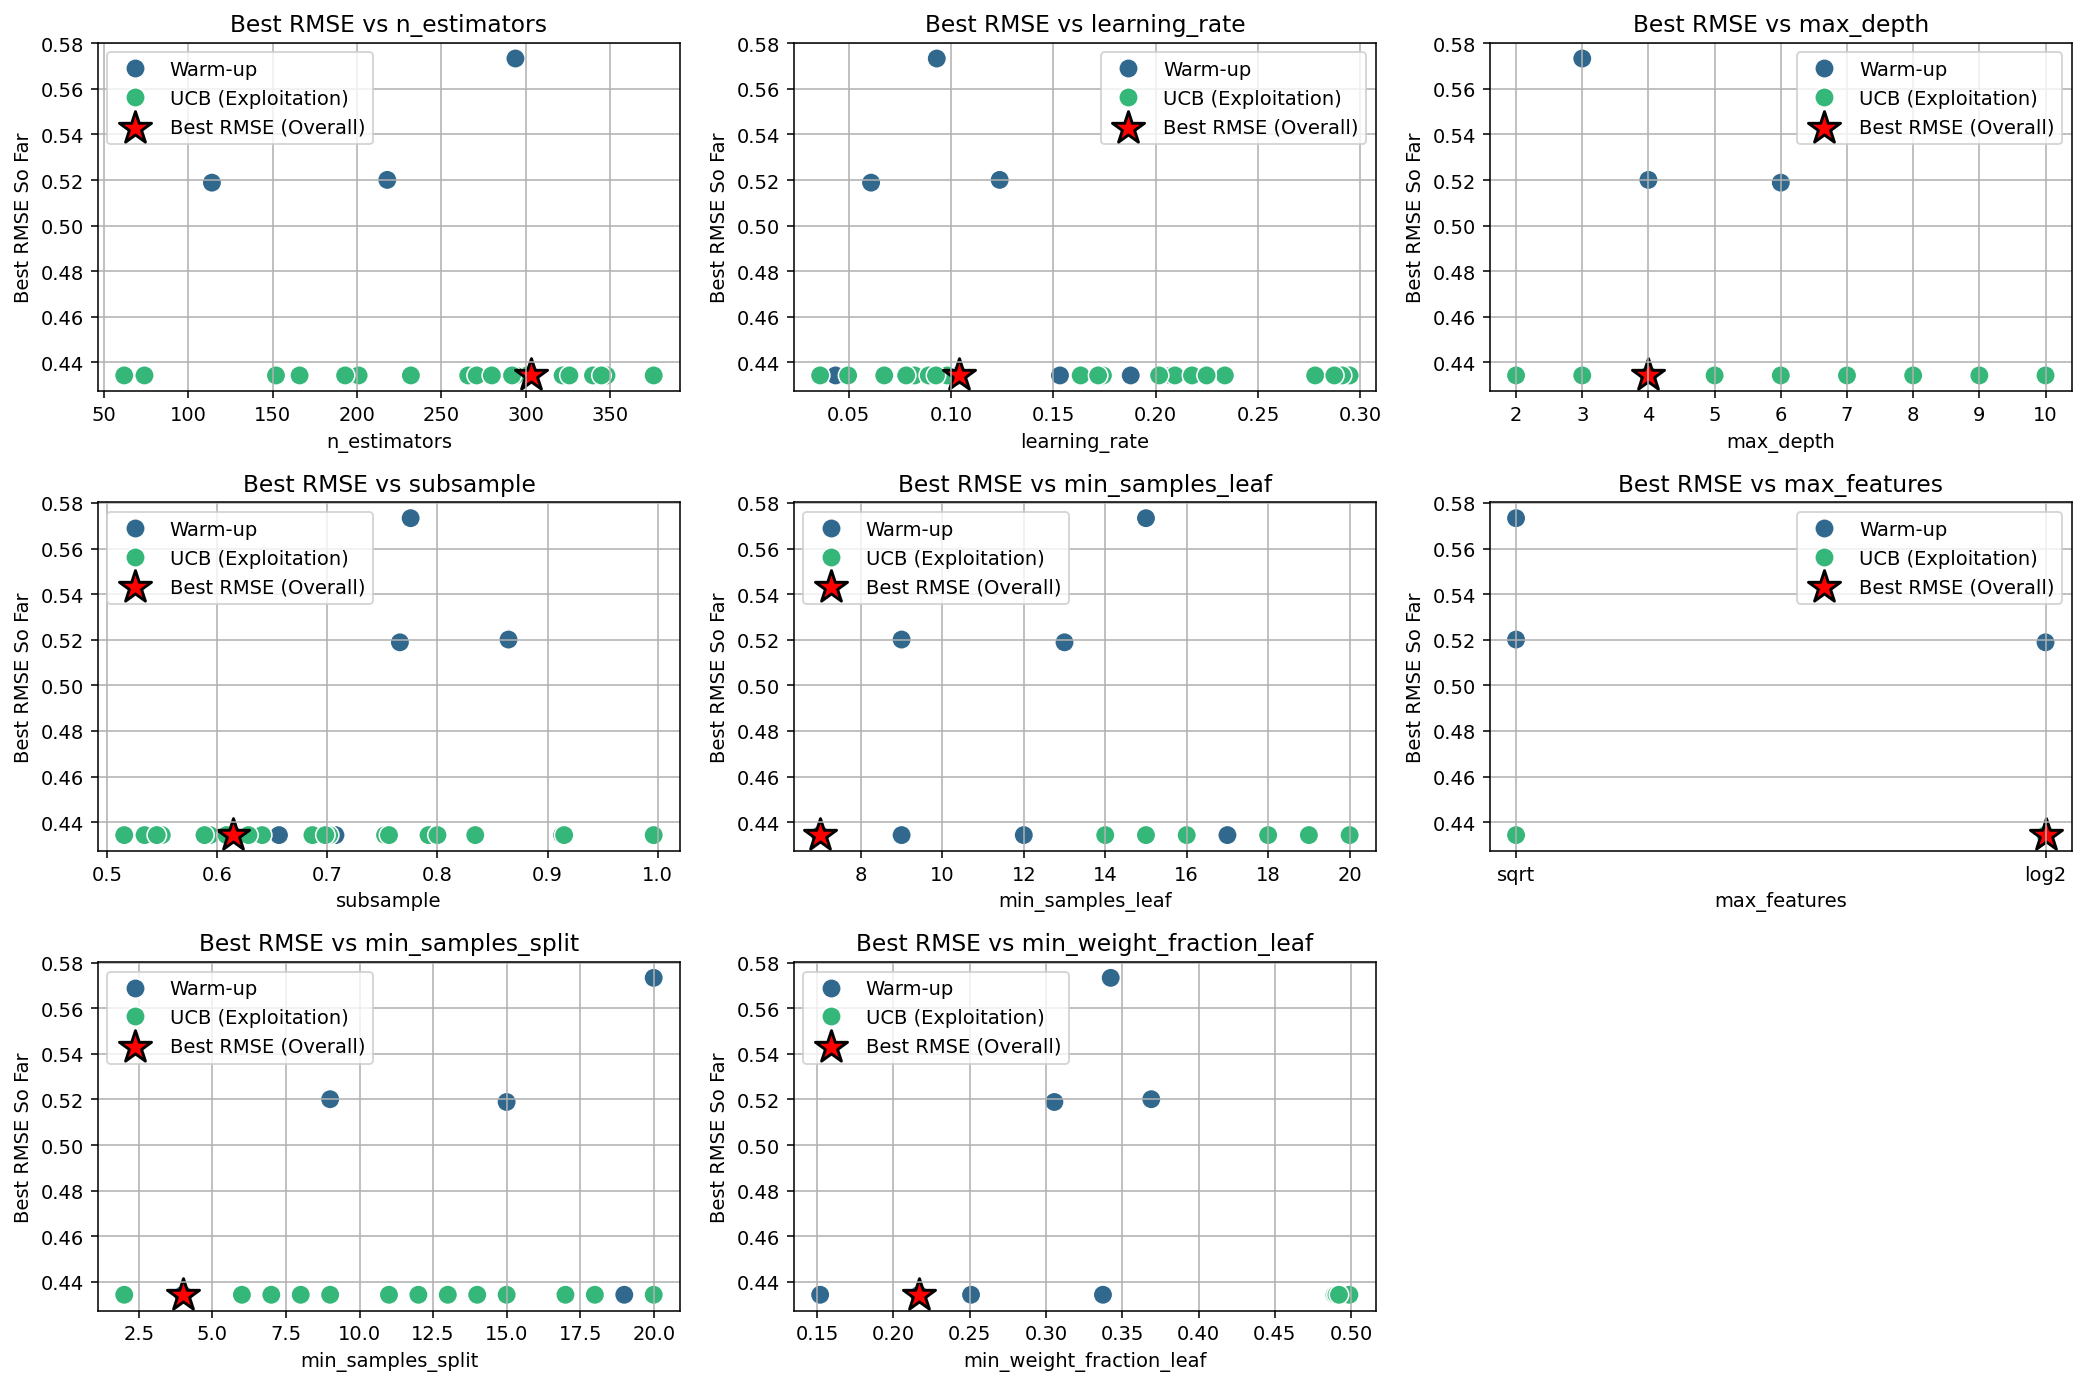

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

hyperparameters = list(space.keys())

plt.figure(figsize=(15, 10))
for i, hp_name in enumerate(hyperparameters):
    plt.subplot(3, 3, i + 1) # Changed to 3x3 grid to accommodate 8 plots
    sns.scatterplot(data=log_df, x=hp_name, y='best_rmse_so_far', hue='tag', palette='viridis', s=100)

    # Get the best Performance Score (Negative RMSE) and its corresponding row across all hyperparameters
    best_metric_val_overall = log_df['best_rmse_so_far'].min() # RMSE is to be minimized, so we look for min()
    best_row = log_df[log_df['best_rmse_so_far'] == best_metric_val_overall].iloc[0]

    # Highlight the best overall Performance Score point for the current hyperparameter
    best_hp_value = best_row[hp_name]
    best_metric_value = best_row['best_rmse_so_far']
    plt.scatter(best_hp_value, best_metric_value, color='red', marker='*', s=300, edgecolor='black', linewidth=1.5, label='Best RMSE (Overall)')

    plt.title(f'Best RMSE vs {hp_name}')
    plt.xlabel(hp_name)
    plt.ylabel('Best RMSE So Far')
    plt.grid(True)
    # Prevent scientific notation for integer axes like n_estimators, max_depth, min_samples_leaf, min_samples_split
    if hp_name in ["n_estimators", "max_depth", "min_samples_leaf", "min_samples_split"]:
        plt.ticklabel_format(useOffset=False, style='plain', axis='x')
    plt.legend()

plt.tight_layout()
plt.show()

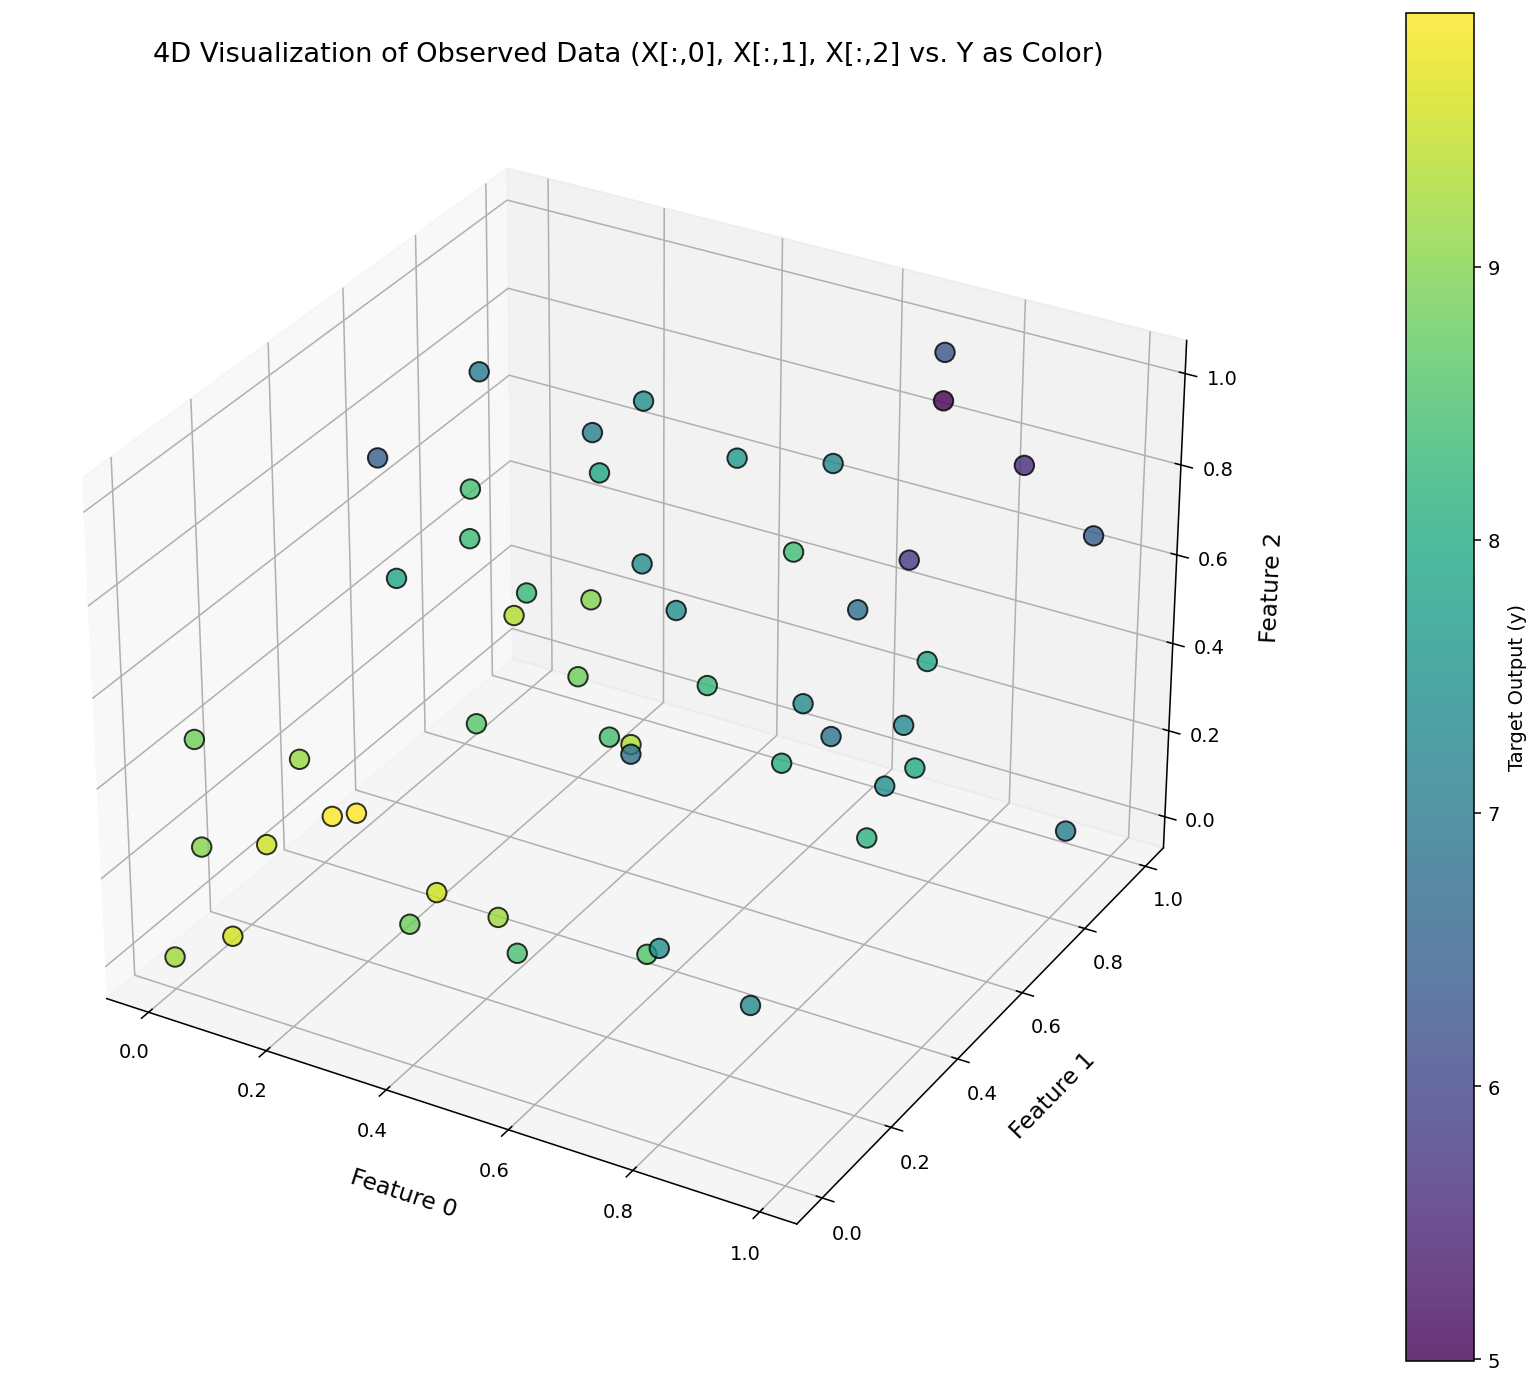

Displayed: 4D Scatter Plot of Observed Data (first 3 features)


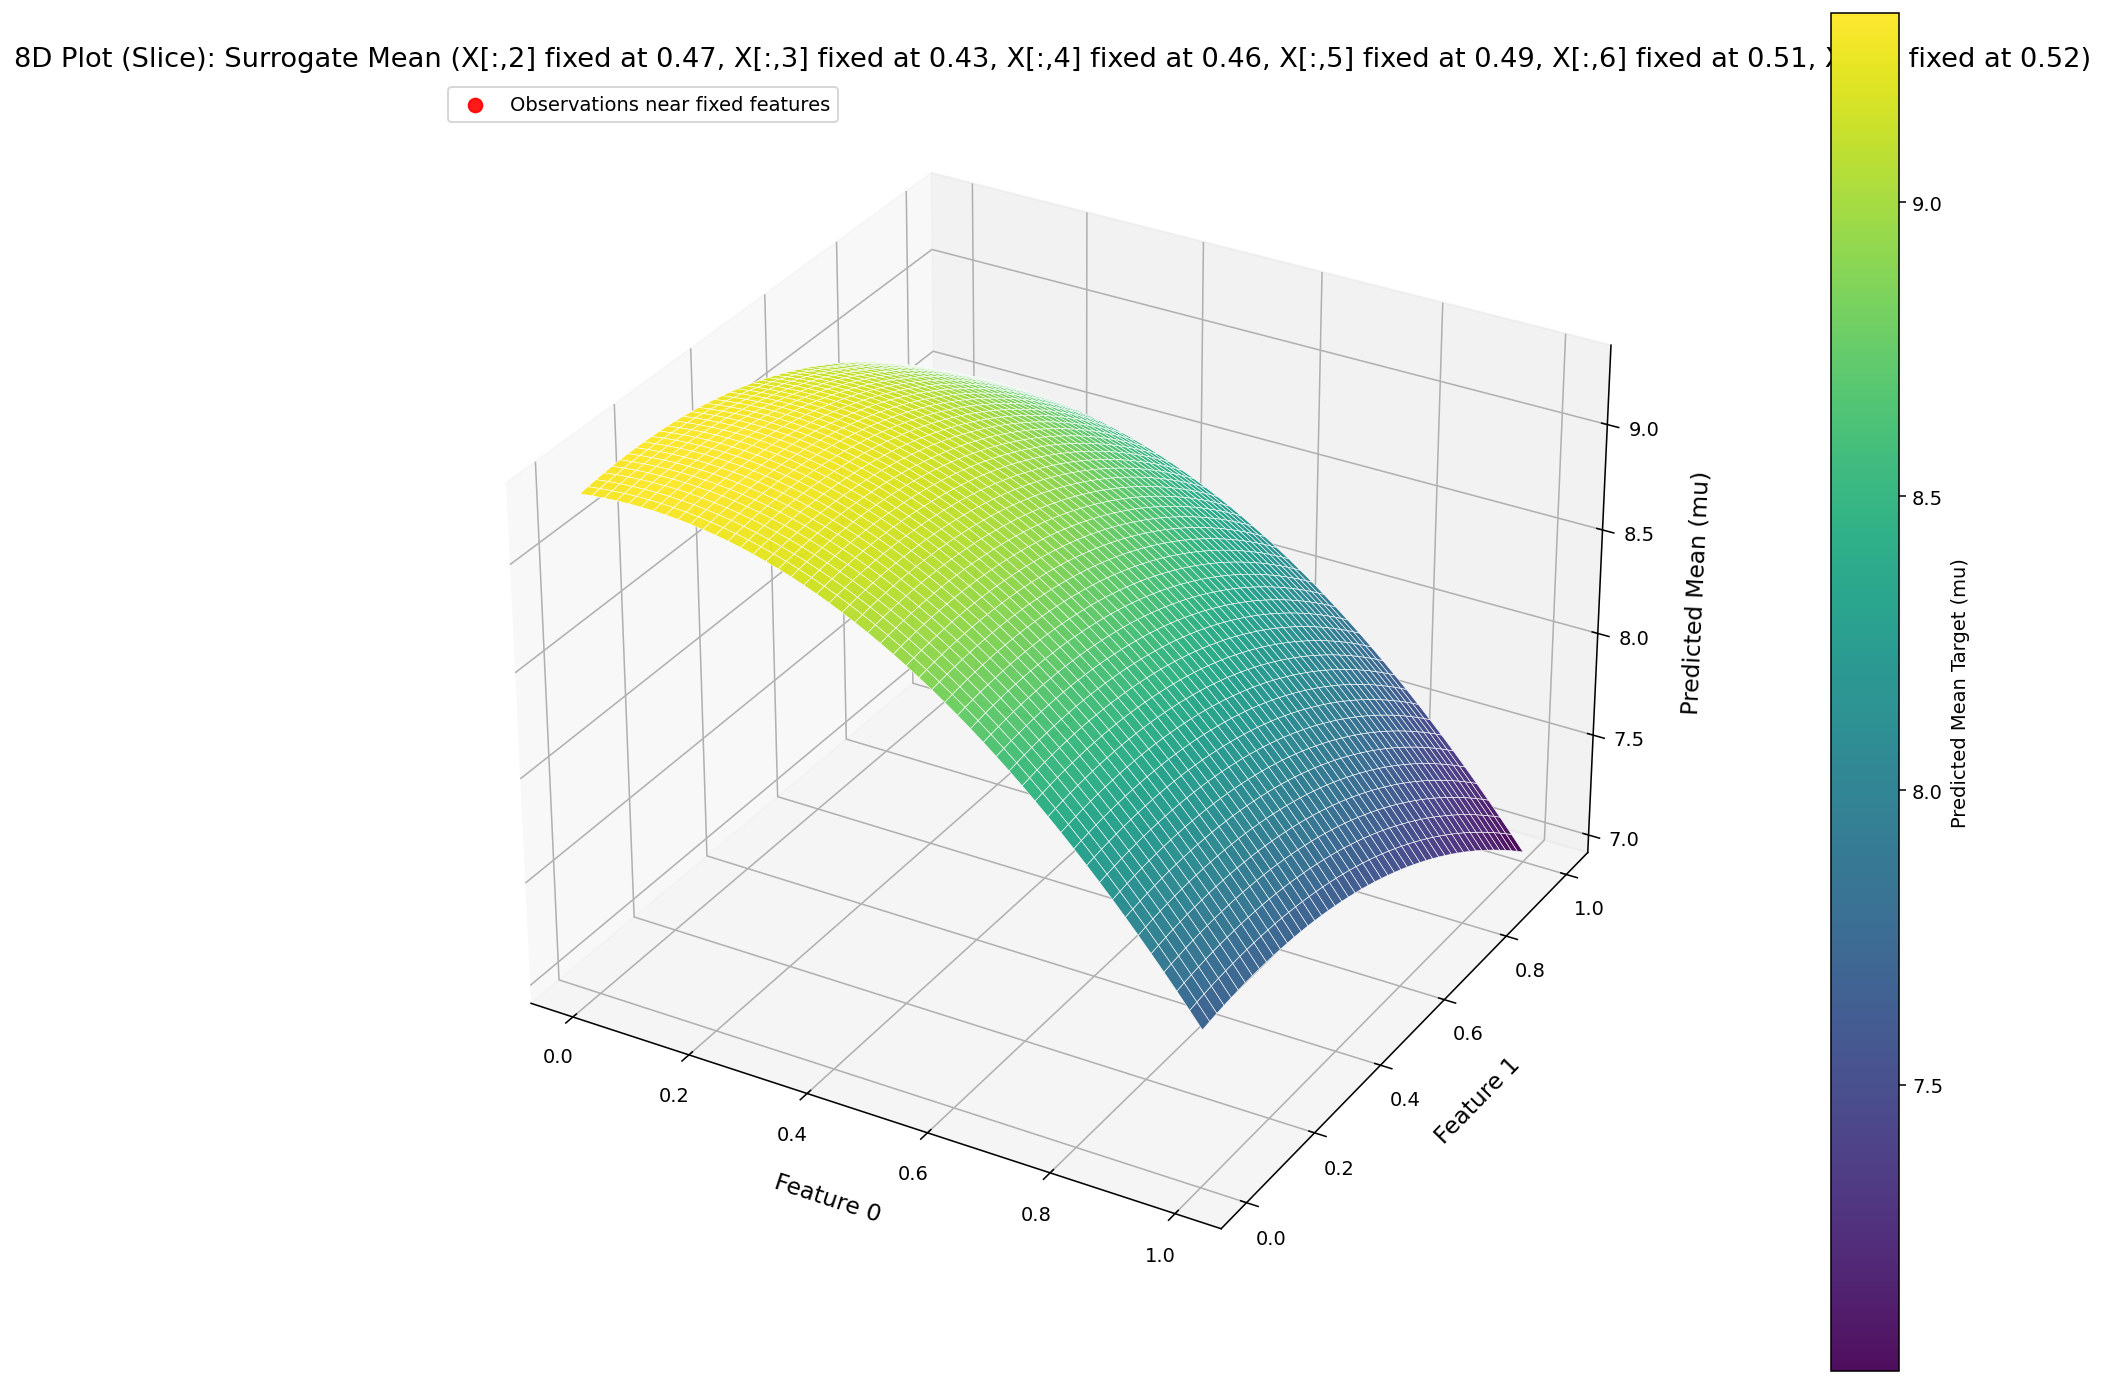

Displayed: 8D Slice Plot for Surrogate Mean (X[:,2] fixed at 0.47, X[:,3] fixed at 0.43, X[:,4] fixed at 0.46, X[:,5] fixed at 0.49, X[:,6] fixed at 0.51, X[:,7] fixed at 0.52)


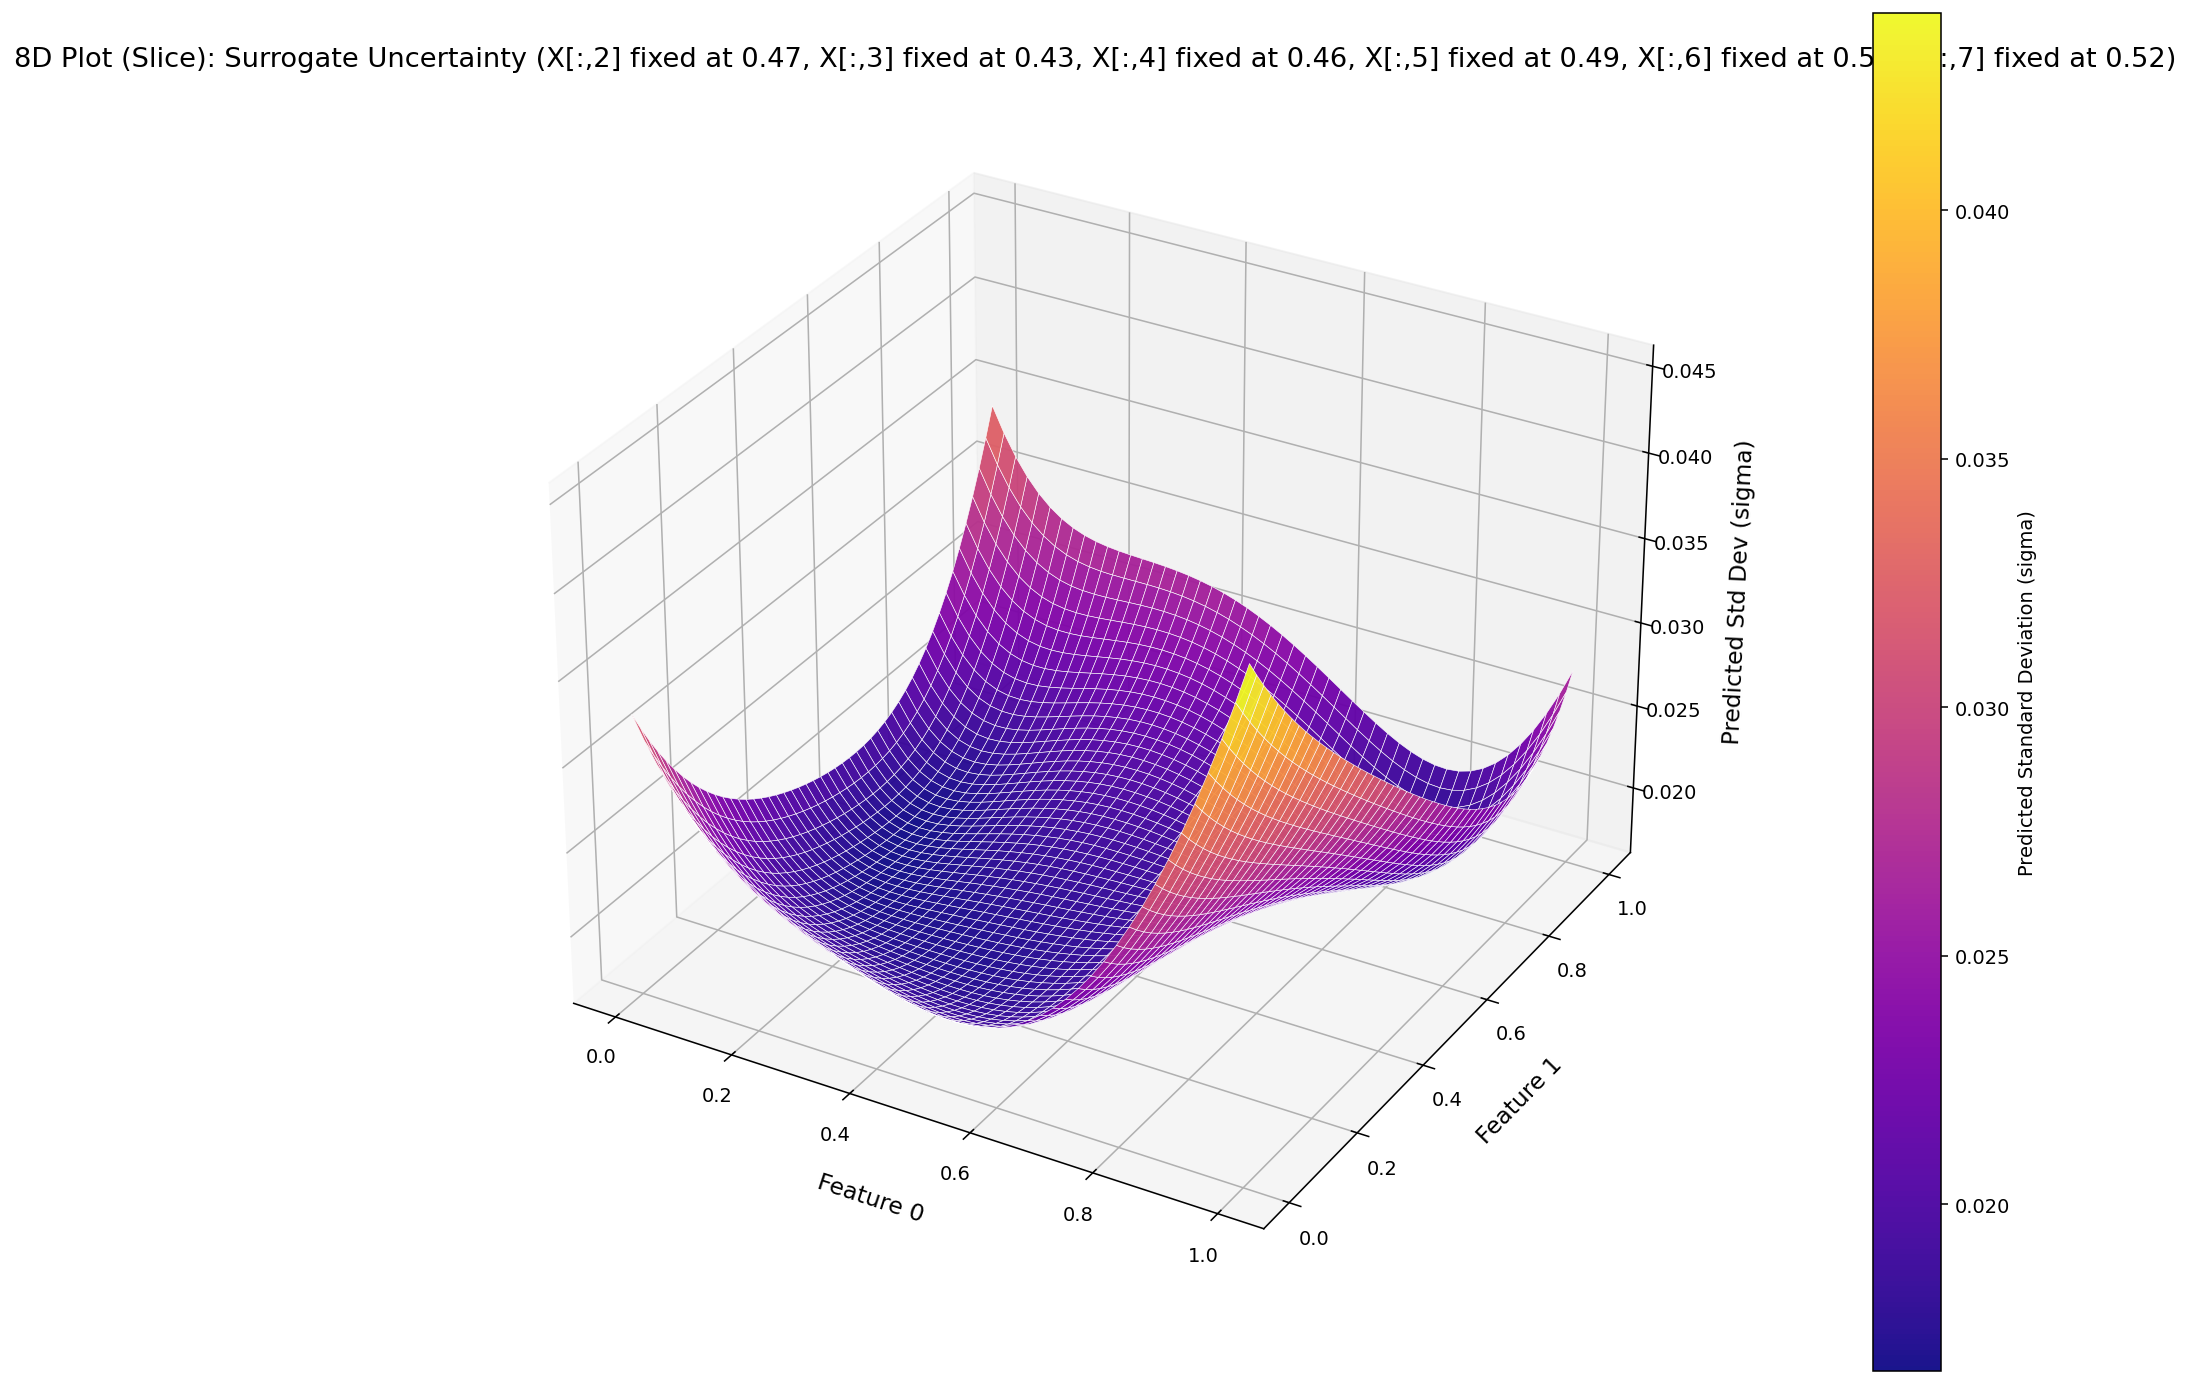

Displayed: 8D Slice Plot for Surrogate Uncertainty (X[:,2] fixed at 0.47, X[:,3] fixed at 0.43, X[:,4] fixed at 0.46, X[:,5] fixed at 0.49, X[:,6] fixed at 0.51, X[:,7] fixed at 0.52)


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

resolution = 50 # Reduced resolution for faster plotting of slices

# Observed data
X_obs = X # Global variable X from the notebook state (8D input)
y_obs = y # Global variable y from the notebook state (1D output)

# Define and fit gpr_3d (renamed to gp for consistency with existing code)
# This block is moved from cell 'sINZlqyUK9eI' to ensure 'gp' is defined.
d_x = X_obs.shape[1] # Dimension of the X input space (should be 8 for the hyperparameters)
kernel_3d = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d_x), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gp = GaussianProcessRegressor(kernel=kernel_3d, normalize_y=True, random_state=42, n_restarts_optimizer=3)
gp.fit(X_obs, y_obs)

# ───────────────────────────────
# 1. 4D Plot: 3D Scatter Plot of Observations with Color representing Y
#    (Visualizing the first 3 features and the target Y)
# ───────────────────────────────
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create a colormap based on the range of y_obs values
scatter = ax.scatter(
    X_obs[:, 0], X_obs[:, 1], X_obs[:, 2],
    c=y_obs, # Color represents the 4th dimension (y_obs)
    cmap='viridis', # Choose a colormap
    s=100, # Marker size
    edgecolor='k', # Black edge for markers
    alpha=0.8
)

# Add a color bar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Target Output (y)')

ax.set_title('4D Visualization of Observed Data (X[:,0], X[:,1], X[:,2] vs. Y as Color)', fontsize=14)
ax.set_xlabel('Feature 0', fontsize=12, labelpad=10)
ax.set_ylabel('Feature 1', fontsize=12, labelpad=10)
ax.set_zlabel('Feature 2', fontsize=12, labelpad=10)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('observed_data_4d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print("Displayed: 4D Scatter Plot of Observed Data (first 3 features)")

# ───────────────────────────────
# 2. 8D Plot (Slice): Surrogate Mean Surface by fixing Features 2 through 7
#    This shows a 3D slice of the 8D surrogate function (2 inputs + 1 output)
# ───────────────────────────────
fig2 = plt.figure(figsize=(12, 10))
ax2 = fig2.add_subplot(111, projection='3d')

# Define ranges for the two features we will vary
x1_min, x1_max = 0, 1
x2_min, x2_max = 0, 1

# Create a grid for X[:,0] and X[:,1]
x1_grid = np.linspace(x1_min, x1_max, resolution)
x2_grid = np.linspace(x2_min, x2_max, resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Fix features 2 through 7 at their mean values
fixed_x_values_for_slice = [np.mean(X_obs[:, i]) for i in range(2, d_x)]

# Create the 8D input grid for prediction for this slice
# Each point will be [X1_val, X2_val, fixed_x2_value, ..., fixed_x7_value]
fixed_parts_for_grid = [np.full(X1.size, val) for val in fixed_x_values_for_slice]
X_slice_grid = np.column_stack([X1.ravel(), X2.ravel()] + fixed_parts_for_grid)


# Predict mean and std for this slice from the GPR
mu_slice, std_slice = gp.predict(X_slice_grid, return_std=True)
Mu_slice_surface = mu_slice.reshape(resolution, resolution)
Std_slice_surface = std_slice.reshape(resolution, resolution)

# Plot the surrogate mean surface
surf_mean = ax2.plot_surface(
    X1, X2, Mu_slice_surface,
    cmap='viridis',
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observed points that are close to the fixed feature values
tolerance = 0.1 # Define a tolerance for "close"
# Create a mask for points close to the mean of fixed features
close_points_mask = np.ones(len(X_obs), dtype=bool)
for i in range(2, d_x):
    mean_val = np.mean(X_obs[:, i])
    close_points_mask = close_points_mask & \
                        ((X_obs[:, i] >= mean_val - tolerance) & (X_obs[:, i] <= mean_val + tolerance))

# Label for fixed features in title
fixed_features_labels = ", ".join([f"X[:,{i}] fixed at {fixed_x_values_for_slice[i-2]:.2f}" for i in range(2, d_x)])

ax2.scatter(
    X_obs[close_points_mask, 0], X_obs[close_points_mask, 1], y_obs[close_points_mask],
    color='red', s=50, zorder=5, label=f'Observations near fixed features', alpha=0.9
)

# Add a color bar for the surface
cbar_mean = fig2.colorbar(surf_mean, ax=ax2, pad=0.1)
cbar_mean.set_label('Predicted Mean Target (mu)')

ax2.set_title(f'8D Plot (Slice): Surrogate Mean ({fixed_features_labels})', fontsize=14)
ax2.set_xlabel('Feature 0', fontsize=12, labelpad=10) # Changed from 'Feature 1' to 'Feature 0' to align with indexing
ax2.set_ylabel('Feature 1', fontsize=12, labelpad=10) # Changed from 'Feature 2' to 'Feature 1'
ax2.set_zlabel('Predicted Mean (mu)', fontsize=12, labelpad=10)
ax2.tick_params(axis='both', labelsize=10)
ax2.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('surrogate_mean_slice_8d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print(f"Displayed: 8D Slice Plot for Surrogate Mean ({fixed_features_labels})")

# ───────────────────────────────
# 3. 8D Plot (Slice): Surrogate Uncertainty Surface by fixing Features 2 through 7
# ───────────────────────────────
fig3 = plt.figure(figsize=(12, 10))
ax3 = fig3.add_subplot(111, projection='3d')

# Plot the surrogate uncertainty surface
surf_std = ax3.plot_surface(
    X1, X2, Std_slice_surface,
    cmap='plasma', # Good for uncertainty
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observed points that are close to the fixed_x_values_for_slice (optional)
ax3.scatter(
    X_obs[close_points_mask, 0], X_obs[close_points_mask, 1], np.zeros_like(y_obs[close_points_mask]), # Project to Z=0 for context
    color='red', s=50, zorder=5, label=f'Observations near fixed features', alpha=0.9
)

# Add a color bar for the uncertainty surface
cbar_std = fig3.colorbar(surf_std, ax=ax3, pad=0.1)
cbar_std.set_label('Predicted Standard Deviation (sigma)')

ax3.set_title(f'8D Plot (Slice): Surrogate Uncertainty ({fixed_features_labels})', fontsize=14)
ax3.set_xlabel('Feature 0', fontsize=12, labelpad=10) # Changed from 'Feature 1' to 'Feature 0'
ax3.set_ylabel('Feature 1', fontsize=12, labelpad=10) # Changed from 'Feature 2' to 'Feature 1'
ax3.set_zlabel('Predicted Std Dev (sigma)', fontsize=12, labelpad=10)
ax3.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('surrogate_uncertainty_slice_8d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print(f"Displayed: 8D Slice Plot for Surrogate Uncertainty ({fixed_features_labels})")


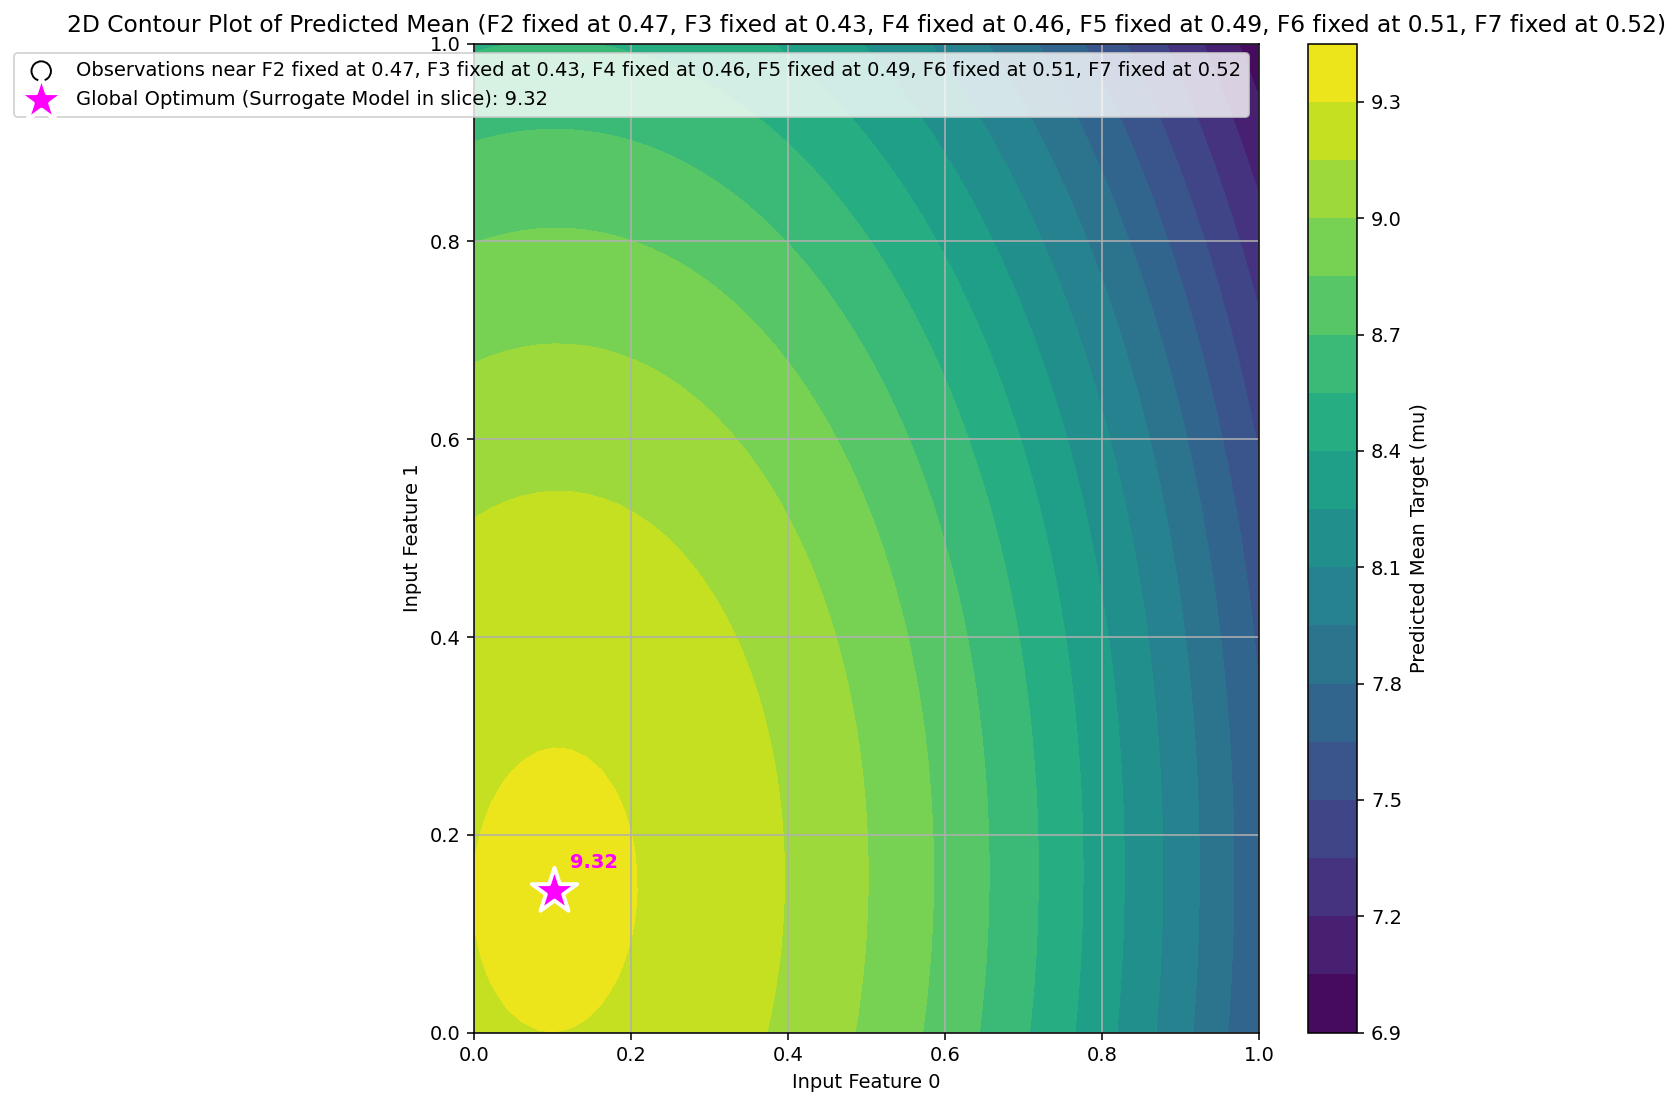

Saved: gp_surrogate_mean_contour_8d_input_slice.png

Global Optimum within slice (X0, X1, fixed X2-X7): [0.10204082 0.14285714 0.4712296  0.42571052 0.46097263 0.48818089
 0.50944903 0.515065  ]
Predicted Mean Target (yield) at this point: 9.32169e+00


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming gpr_3d, X, y, next_x_data_point, predicted_y_at_next_x are available from previous cells.

# Get the total number of dimensions from X
d_x = X.shape[1] # Should be 8

# Define parameters for the 2D slice visualization (fixing Features 2 through 7)
# Using mean values of observed data for fixed features, so Features 0 and 1 will vary.
fixed_x_values_for_slice = [np.mean(X[:, i]) for i in range(2, d_x)] # Features 2 to 7

resolution = 50 # Resolution for the grid of the 2D slice

# Create a grid for X[:,0] and X[:,1]
x1_grid = np.linspace(0, 1, resolution)
x2_grid = np.linspace(0, 1, resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Create the 8D input grid for prediction for this slice
# Each point will be [X1_val, X2_val, fixed_x2_value, ..., fixed_x7_value]
fixed_parts_for_grid = [np.full(X1.size, val) for val in fixed_x_values_for_slice]
X_slice_grid = np.column_stack([X1.ravel(), X2.ravel()] + fixed_parts_for_grid)

# Predict mean from the fitted GPR (gpr_3d)
mu_slice, _ = gpr_3d.predict(X_slice_grid, return_std=True)
Mu_slice_surface = mu_slice.reshape(resolution, resolution)

fig, ax = plt.subplots(figsize=(10, 8)) # Get fig and ax objects
contour = ax.contourf(X1, X2, Mu_slice_surface, levels=20, cmap='viridis')
fig.colorbar(contour, ax=ax, label='Predicted Mean Target (mu)')

# Scatter the observed points that are close to the fixed feature values
tolerance = 0.1 # Define a tolerance for "close"
close_points_mask = np.ones(len(X), dtype=bool)
for i, fixed_val in enumerate(fixed_x_values_for_slice):
    current_feature_idx = i + 2 # Corresponds to X[:, 2], X[:, 3], ..., X[:, 7]
    close_points_mask = close_points_mask & \
                        ((X[:, current_feature_idx] >= fixed_val - tolerance) & \
                         (X[:, current_feature_idx] <= fixed_val + tolerance))

# Label for fixed features in title and legend
fixed_features_labels = ", ".join([f"F{i+2} fixed at {val:.2f}" for i, val in enumerate(fixed_x_values_for_slice)])

ax.scatter(
    X[close_points_mask, 0], X[close_points_mask, 1], c=y[close_points_mask],
    cmap='viridis', s=100, edgecolors='k', label=f'Observations near {fixed_features_labels}'
)

# Mark the suggested next sample point (if it falls within this slice)
# Check if the suggested next sample point falls within this slice based on the fixed features
next_x_is_in_slice = True
for i, fixed_val in enumerate(fixed_x_values_for_slice):
    current_feature_idx = i + 2
    if not np.isclose(next_x_data_point[current_feature_idx], fixed_val, atol=tolerance):
        next_x_is_in_slice = False
        break

if next_x_is_in_slice:
    ax.scatter(next_x_data_point[0], next_x_data_point[1],
                color='red', marker='X', s=200, label='Suggested Next Sample Point', zorder=5)

# Find the global maximum of Mu_slice_surface (as we are maximizing the transformed output)
# This is the global optimum *within this specific 2D slice* (for the two varying features)
max_mu_slice_idx = np.argmax(Mu_slice_surface)
# Get the 8D coordinates of this point within the slice
max_mu_slice_coords_flattened = X_slice_grid[max_mu_slice_idx] # X_slice_grid is now 8D
max_mu_value_in_slice = Mu_slice_surface.max()

ax.scatter(
    max_mu_slice_coords_flattened[0], max_mu_slice_coords_flattened[1],
    color='magenta', marker='*', s=600, zorder=10, edgecolor='white', linewidth=2,
    label=f'Global Optimum (Surrogate Model in slice): {max_mu_value_in_slice:.2f}'
)

# Add text annotation for clarity
ax.text(max_mu_slice_coords_flattened[0] + 0.02, max_mu_slice_coords_flattened[1] + 0.02,
         f'{max_mu_value_in_slice:.2f}', color='magenta', fontsize=10, ha='left', va='bottom', weight='bold')

ax.set_title(f'2D Contour Plot of Predicted Mean ({fixed_features_labels})')
ax.set_xlabel('Input Feature 0')
ax.set_ylabel('Input Feature 1')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('gp_surrogate_mean_contour_8d_input_slice.png', dpi=150, bbox_inches='tight') # Updated filename
plt.show()
print("Saved: gp_surrogate_mean_contour_8d_input_slice.png") # Updated filename
print(f"\nGlobal Optimum within slice (X0, X1, fixed X2-X7): {max_mu_slice_coords_flattened}") # Updated print statement
print(f"Predicted Mean Target (yield) at this point: {max_mu_value_in_slice:.5e}")

In [30]:
import numpy as np

# --- 1. Global Maximum identified from Observed Data (y) ---
max_y_observed = np.max(y)
max_y_observed_idx = np.argmax(y)
max_X_observed = X[max_y_observed_idx]

print(f"\nObserved Global Maximum 'y' value: {max_y_observed:.5e}")
print(f"Corresponding 'X' values (Index {max_y_observed_idx}): {max_X_observed}")

# --- 2. Predicted Global Maximum (based on Surrogate Model gpr_3d) ---
# The gpr_3d model was already fitted in cell '4HScECjpuxOK' on X and y
# We will use the 'mu_3d' array which contains the predicted mean 'y' values for 'candidates_3d'

# Find the index of the maximum predicted mean 'y' value among all candidates
predicted_global_max_idx = np.argmax(mu_3d)
predicted_global_max_y = mu_3d[predicted_global_max_idx]
predicted_global_max_X = candidates_3d[predicted_global_max_idx]

# Get the uncertainty (standard deviation) at this predicted global maximum point
predicted_global_max_std = std_3d[predicted_global_max_idx]

print(f"\nPredicted Global Maximum 'y' value (from surrogate mean): {predicted_global_max_y:.5e}")
print(f"Corresponding 'X' values: {predicted_global_max_X}")
print(f"Uncertainty (std) at this predicted point: {predicted_global_max_std:.5e}")


Observed Global Maximum 'y' value: 9.92896e+00
Corresponding 'X' values (Index 51): [0.081722 0.297324 0.141278 0.123001 0.780008 0.682824 0.211503 0.230336]

Predicted Global Maximum 'y' value (from surrogate mean): 9.92221e+00
Corresponding 'X' values: [0.11953696 0.15646891 0.02495981 0.25593076 0.82122589 0.54610068
 0.18477835 0.40991395]
Uncertainty (std) at this predicted point: 2.99943e-02
